In [3]:
print('h')

h


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime

pd.set_option('display.max_rows', None)  
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)  
pd.set_option('display.max_colwidth', None) 

indexes_dict = {
    # ОСНОВНЫЕ РЫНОЧНЫЕ ИНДЕКСЫ
    'SPX': 'S&P 500', # 500 крупнейших компаний США
    'MID': 'S&P 400 Mid Cap', # по средней капитализацией между large и small cap
    'OEX': 'S&P 100', # 100 крупнейших компаний из S&P 500
    'SPGSCI': 'S&P GSCI Commodity', # Товарный индекс - сырье, энергия, сельхозпродукция
    'DJI': 'Dow Jones Industrial', # 30 промышленных гигантов - иконы американского бизнеса
    'IXIC': 'NASDAQ Composite', # Все компании NASDAQ (~3000 акций)
    'NDX': 'NASDAQ 100', # 100 крупнейших нефинансовых компаний NASDAQ
    'RUT': 'Russell 2000 Small Cap',# 2000 мелких компаний - индикатор внутренней экономики
    'VIX': 'CBOE Volatility',# Индекс страха - ожидаемая волатильность S&P 500 
    # ОТРАСЛЕВЫЕ ИНДЕКСЫ
    'OSX': 'PHLX Oil Service', # Нефтесервисные компании - бурение, оборудование, услуги
    'SOX': 'PHLX Semiconductor', # Производители чипов
    'XAU': 'PHLX Gold/Silver', # Золотодобывающие компании
    'HGX': 'PHLX Housing', # Строительные компании - застройщики, поставщики материалов
    'UTY': 'PHLX Utilities',# Коммунальные предприятия - электроэнергия, газ, вода
    'SPSIBI': 'S&P Biotechnology', # Биотехнологические компании - фарма, медтехнологии
    'SPSIOP': 'S&P Oil & Gas Exploration', # Нефтегазовые компании - разведка и добыча
    # ДОПОЛНИТЕЛЬНЫЕ СЕКТОРАЛЬНЫЕ
    'TRAN': 'NASDAQ Transportation', # Транспортные компании - авиаперевозки, логистика, грузы
    'IXTC': 'NASDAQ Telecommunications', # Телекоммуникационные компании - связь, интернет, мобильные услуги
    'IXCO': 'NASDAQ Computer', # Производители компьютеров и ПО - hardware и software
    'INSR': 'NASDAQ Insurance' # Страховые компании - жизнь, здоровье, имущество
}



In [5]:
"""
mass = []
period = '17y'
for tiker, name in indexes_dict.items():
    try:
        time.sleep(0.5)
        index = yf.Ticker('^' + tiker)
        history = index.history(period=period)
        if history.empty:
            print('not load' + name)
            continue
        history['Ticker'] = tiker
        history['Name'] = name
        mass.append(history)
        print('load ' + name)
    except Exception as e:
        print("Error for "+tiker)
"""

'\nmass = []\nperiod = \'17y\'\nfor tiker, name in indexes_dict.items():\n    try:\n        time.sleep(0.5)\n        index = yf.Ticker(\'^\' + tiker)\n        history = index.history(period=period)\n        if history.empty:\n            print(\'not load\' + name)\n            continue\n        history[\'Ticker\'] = tiker\n        history[\'Name\'] = name\n        mass.append(history)\n        print(\'load \' + name)\n    except Exception as e:\n        print("Error for "+tiker)\n'

In [6]:
"""
df = pd.concat(mass)
df.to_csv('Main_indexs.csv')
df.reset_index(inplace=True)

df.sample(10)
"""


"\ndf = pd.concat(mass)\ndf.to_csv('Main_indexs.csv')\ndf.reset_index(inplace=True)\n\ndf.sample(10)\n"

# Описание
Open - цена открытия на момент Data

High - максимальная цена Higt

Low - минимальная цена

Close - цена закрытия

Volume - объем (сколько совершено сделок)

Dividends - дивиденды

Stock Splits - сплиты акции


In [3]:
df = pd.read_csv("Main_indexs.csv")
df['Date'] = pd.to_datetime(df['Date'], utc=True)
df.head(10)

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker,Name
0,2008-10-31 04:00:00+00:00,953.109985,984.380005,944.590027,968.750000,6394350000,0.0,0.0,SPX,S&P 500
1,2008-11-03 05:00:00+00:00,968.669983,975.570007,958.820007,966.299988,4492280000,0.0,0.0,SPX,S&P 500
2,2008-11-04 05:00:00+00:00,971.309998,1007.510010,971.309998,1005.750000,5531290000,0.0,0.0,SPX,S&P 500
3,2008-11-05 05:00:00+00:00,1001.840027,1001.840027,949.859985,952.770020,5426640000,0.0,0.0,SPX,S&P 500
4,2008-11-06 05:00:00+00:00,952.400024,952.400024,899.729980,904.880005,6102230000,0.0,0.0,SPX,S&P 500
5,2008-11-07 05:00:00+00:00,907.440002,931.460022,906.900024,930.989990,4931640000,0.0,0.0,SPX,S&P 500
6,2008-11-10 05:00:00+00:00,936.750000,951.950012,907.469971,919.210022,4572000000,0.0,0.0,SPX,S&P 500
7,2008-11-11 05:00:00+00:00,917.150024,917.150024,884.900024,898.950012,4998340000,0.0,0.0,SPX,S&P 500
8,2008-11-12 05:00:00+00:00,893.390015,893.390015,850.479980,852.299988,5764180000,0.0,0.0,SPX,S&P 500
9,2008-11-13 05:00:00+00:00,853.130005,913.010010,818.690002,911.289978,7849120000,0.0,0.0,SPX,S&P 500


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76965 entries, 0 to 76964
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   Date          76965 non-null  datetime64[ns, UTC]
 1   Open          76965 non-null  float64            
 2   High          76965 non-null  float64            
 3   Low           76965 non-null  float64            
 4   Close         76965 non-null  float64            
 5   Volume        76965 non-null  int64              
 6   Dividends     76965 non-null  float64            
 7   Stock Splits  76965 non-null  float64            
 8   Ticker        76965 non-null  object             
 9   Name          76965 non-null  object             
dtypes: datetime64[ns, UTC](1), float64(6), int64(1), object(2)
memory usage: 5.9+ MB


In [5]:
df.shape

(76965, 10)

In [6]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,76965.000000,76965.000000,76965.000000,76965.000000,7.696500e+04,76965.0,76965.0
mean,3759.883957,3784.447883,3733.989297,3760.651525,1.056989e+09,0.0,0.0
std,6466.750321,6503.834304,6427.580674,6468.028262,1.902517e+09,0.0,0.0
min,9.010000,9.310000,8.560000,9.140000,0.000000e+00,0.0,0.0
25%,359.559998,362.880005,355.619995,359.359985,0.000000e+00,0.0,0.0
50%,1182.719971,1190.680054,1172.880005,1182.449951,0.000000e+00,0.0,0.0
75%,4078.229980,4104.669922,4053.110107,4079.159912,1.839790e+09,0.0,0.0
max,47752.351562,48040.640625,47675.699219,47706.371094,9.397454e+10,0.0,0.0


In [7]:
df.describe(include='object')

,Ticker,Name
count,76965,76965
unique,20,20
top,SPX,S&P 500
freq,4276,4276


In [8]:
df.isnull().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
Ticker          0
Name            0
dtype: int64

In [9]:
df.isna().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
Ticker          0
Name            0
dtype: int64

## Вывод
1. В общем датасете отстуствуют пропуски в данных;
2. Столбцы "Dividends" и "Stock Splits" не имееют смысла при рассмотрении Индексов => избавиться от них
3. Видно, что за исключением созданных мной столбцов, другие имееют числовой тип => что в данных нет ошибочных данных

## Проверим на выбросы каждый слобец

In [10]:
df = df.drop(['Dividends', 'Stock Splits'], axis=1)

In [11]:
df.sample(10)

,Date,Open,High,Low,Close,Volume,Ticker,Name
69234,2012-02-06 05:00:00+00:00,1538.219971,1543.750000,1533.250000,1543.660034,0,IXCO,NASDAQ Computer
25073,2023-07-07 04:00:00+00:00,13668.070312,13804.509766,13656.730469,13660.719727,5098120000,IXIC,NASDAQ Composite
74272,2015-02-18 05:00:00+00:00,6662.770020,6690.720215,6654.930176,6690.720215,0,INSR,NASDAQ Insurance
11814,2021-10-18 04:00:00+00:00,2050.290039,2063.399902,2042.040039,2062.229980,3662010000,OEX,S&P 100
2602,2019-03-07 05:00:00+00:00,2766.530029,2767.250000,2739.090088,2748.929932,3932150000,SPX,S&P 500
21851,2010-09-16 04:00:00+00:00,2297.510010,2304.949951,2288.709961,2303.250000,1809280000,IXIC,NASDAQ Composite
58356,2019-11-07 05:00:00+00:00,799.039978,799.080017,786.500000,791.739990,0,UTY,PHLX Utilities
58865,2021-11-15 05:00:00+00:00,878.409973,885.700012,876.489990,885.580017,0,UTY,PHLX Utilities
57493,2016-06-06 04:00:00+00:00,626.989990,628.280029,622.320007,625.159973,0,UTY,PHLX Utilities
28849,2021-07-12 04:00:00+00:00,14878.709961,14899.459961,14813.790039,14877.889648,3897090000,NDX,NASDAQ 100


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
def data_out(data, colum, categorya):
    
    df2 = df[df['Ticker']==categorya].copy()
    df2['year'] = df2['Date'].dt.year
    out = False
    mass_year = sorted(df2['year'].unique())
    for year in mass_year:
        df_year = df2[df2['year'] == year]
        q1 = df_year[colum].quantile(0.25)
        q3 = df_year[colum].quantile(0.75)
        IQR = q3 - q1
        lw_b = q1 - 1.5 * IQR
        up_b = q3 + 1.5 *IQR
        test = df_year[(df_year[colum] < lw_b) | (df_year[colum] > up_b)]
        print(f'Для {categorya} - {colum} - {year} количество выбросов: {len(test)} это {round((len(test) / len(df2)) * 100,2)} %')
        if len(test) != 0:
            out = True
    return out

mass_out = []
cols = ['Open', 'High', 'Low', 'Close', 'Volume']
cat = df['Ticker'].unique()
for arg_cat in cat:
    for arg_col in cols:
        res = data_out(df,arg_col, arg_cat)
        if res:
             mass_out.append({'tick':arg_cat, 'col':arg_col})




Для SPX - Open - 2008 количество выбросов: 2 это 0.05 %
Для SPX - Open - 2009 количество выбросов: 0 это 0.0 %
Для SPX - Open - 2010 количество выбросов: 0 это 0.0 %
Для SPX - Open - 2011 количество выбросов: 0 это 0.0 %
Для SPX - Open - 2012 количество выбросов: 0 это 0.0 %
Для SPX - Open - 2013 количество выбросов: 0 это 0.0 %
Для SPX - Open - 2014 количество выбросов: 0 это 0.0 %
Для SPX - Open - 2015 количество выбросов: 9 это 0.21 %
Для SPX - Open - 2016 количество выбросов: 4 это 0.09 %
Для SPX - Open - 2017 количество выбросов: 0 это 0.0 %
Для SPX - Open - 2018 количество выбросов: 7 это 0.16 %
Для SPX - Open - 2019 количество выбросов: 4 это 0.09 %
Для SPX - Open - 2020 количество выбросов: 8 это 0.19 %
Для SPX - Open - 2021 количество выбросов: 0 это 0.0 %
Для SPX - Open - 2022 количество выбросов: 0 это 0.0 %
Для SPX - Open - 2023 количество выбросов: 0 это 0.0 %
Для SPX - Open - 2024 количество выбросов: 0 это 0.0 %
Для SPX - Open - 2025 количество выбросов: 2 это 0.05 %
Для

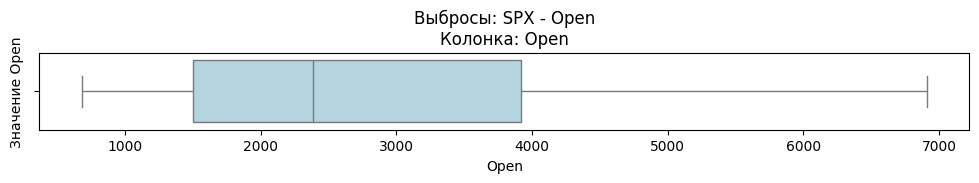

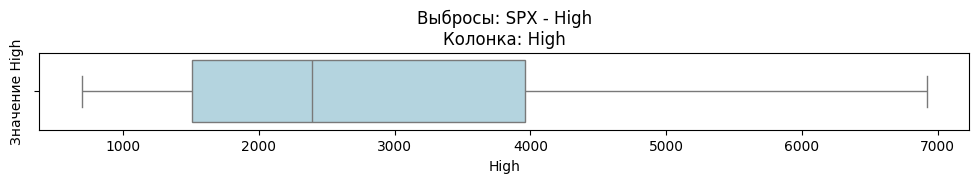

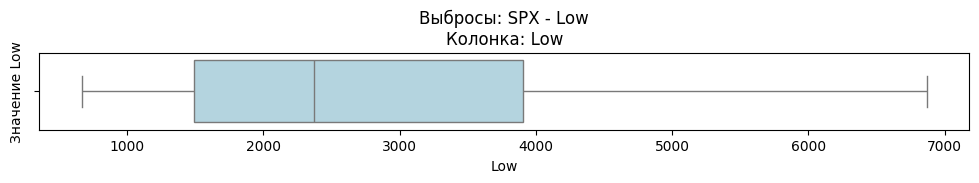

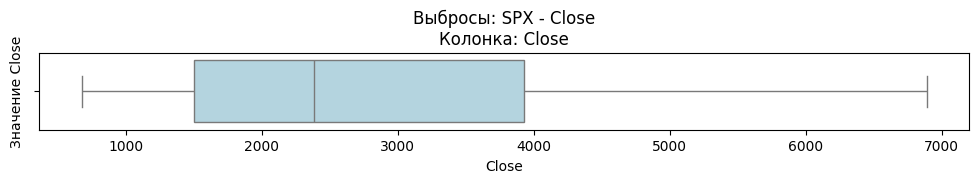

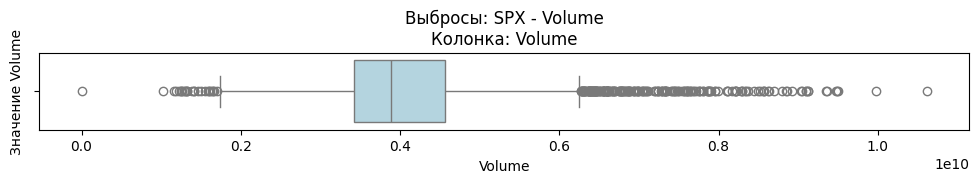

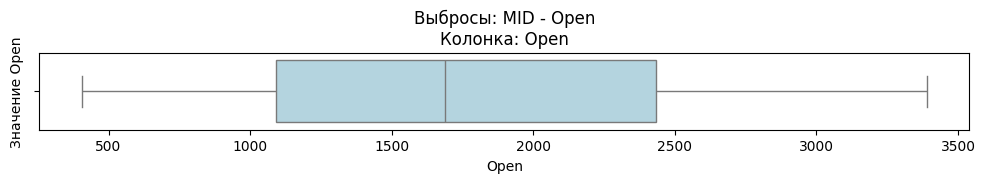

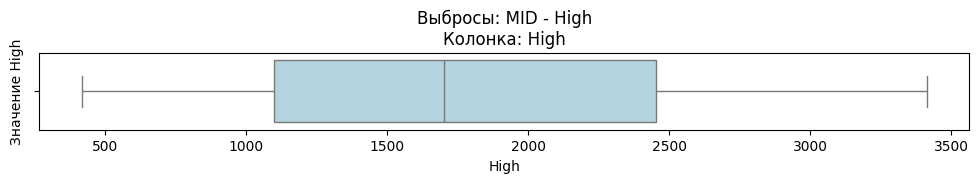

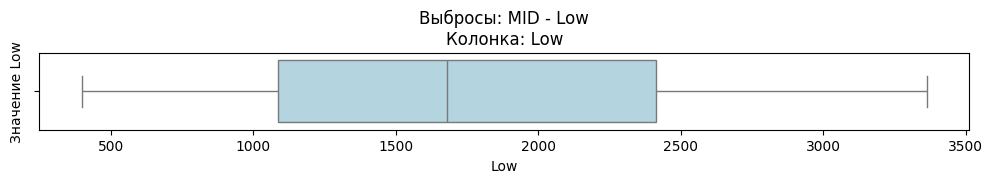

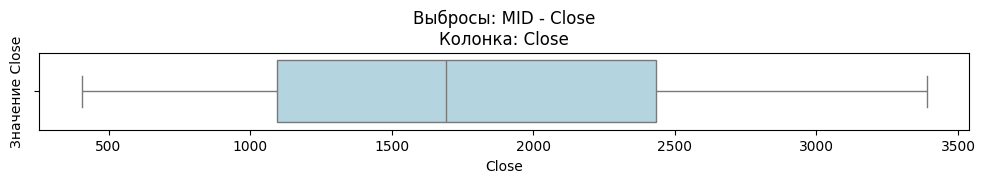

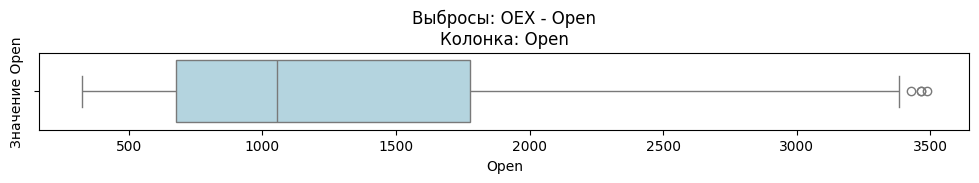

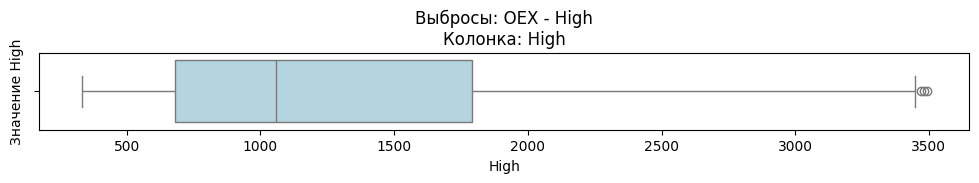

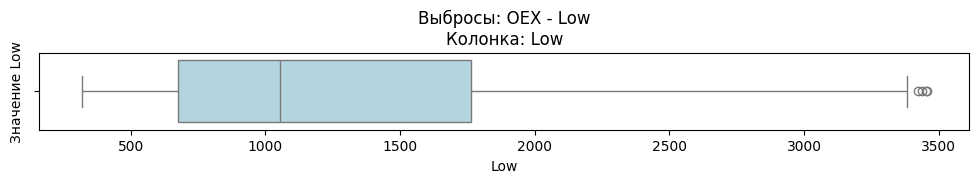

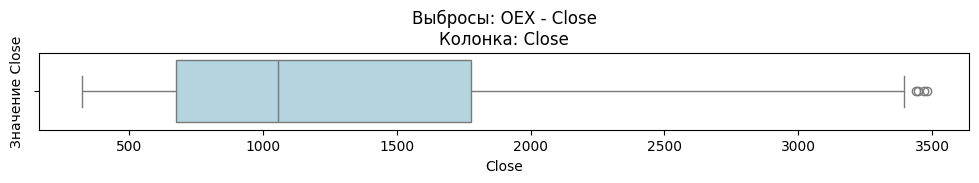

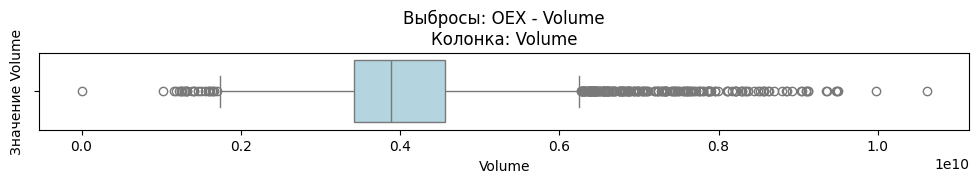

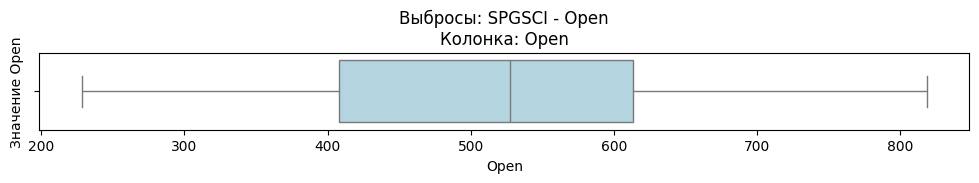

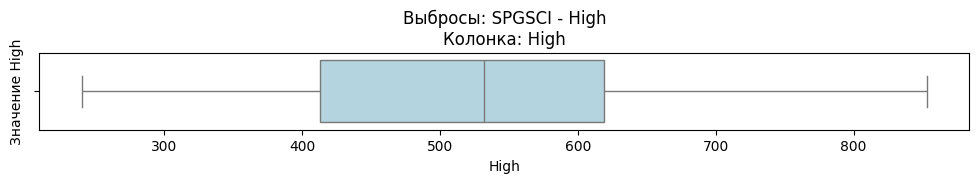

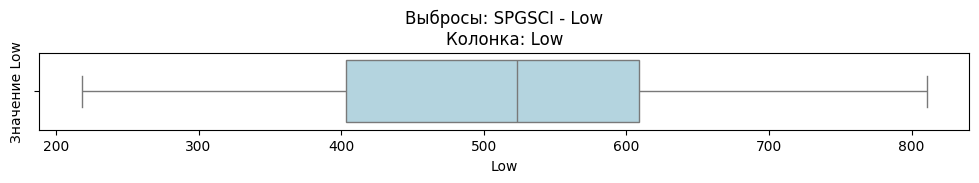

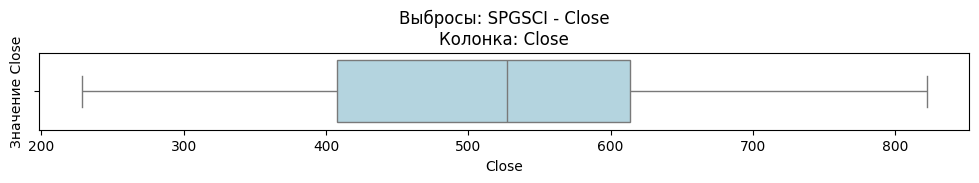

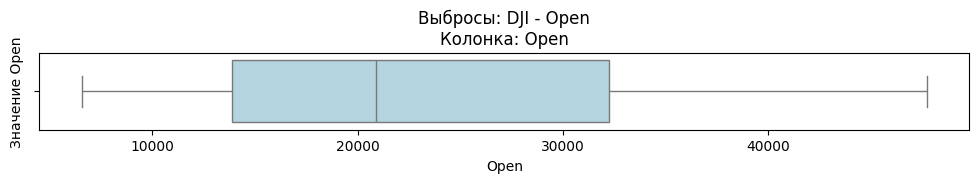

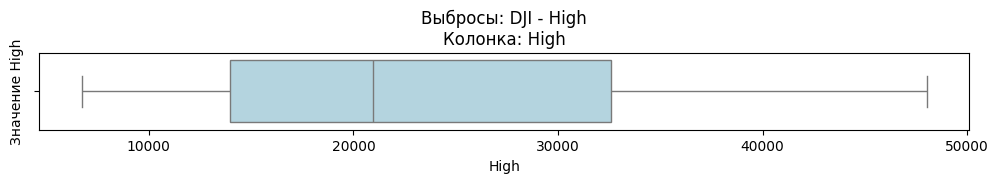

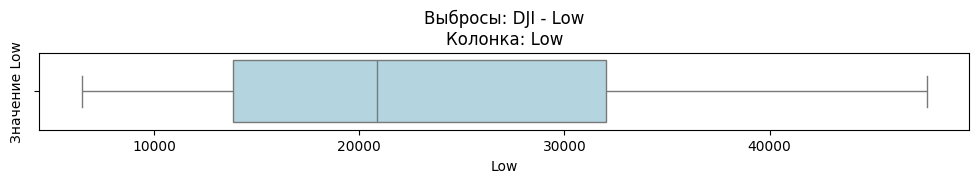

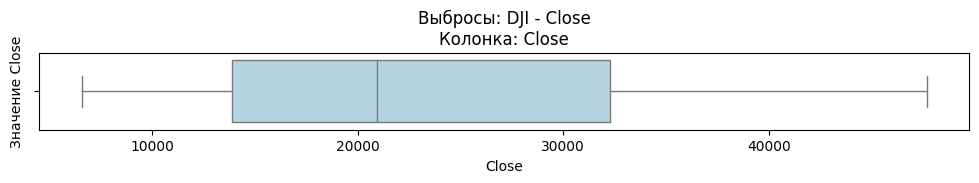

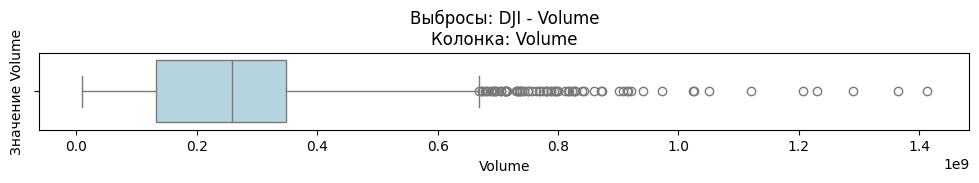

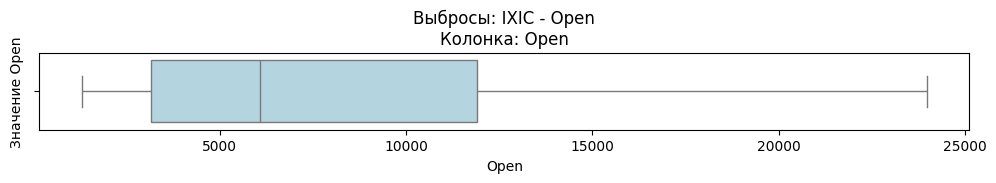

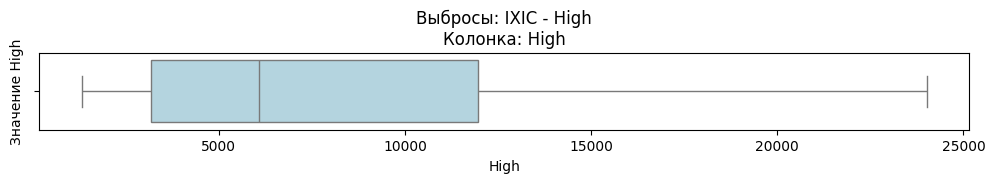

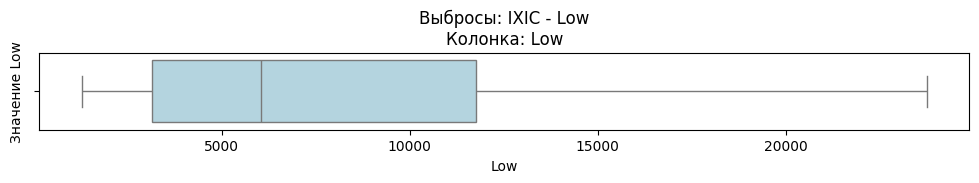

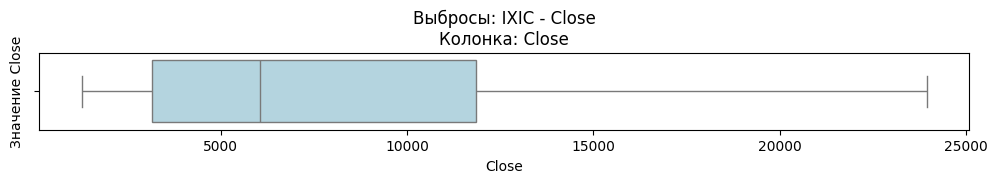

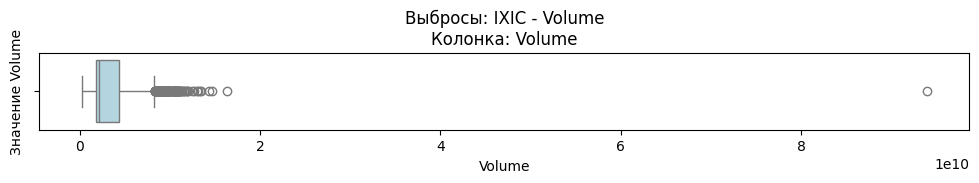

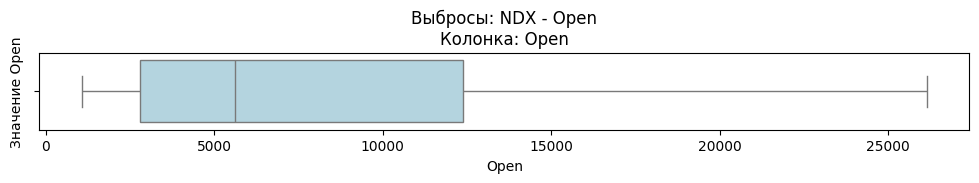

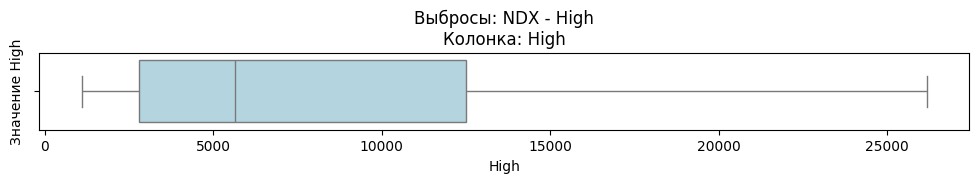

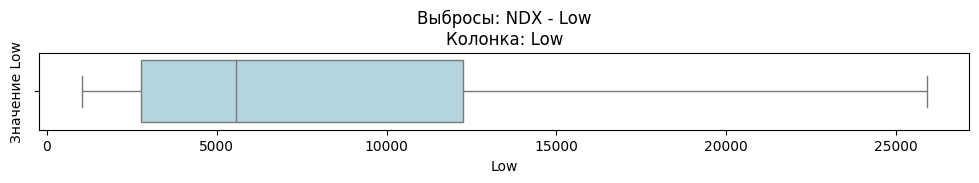

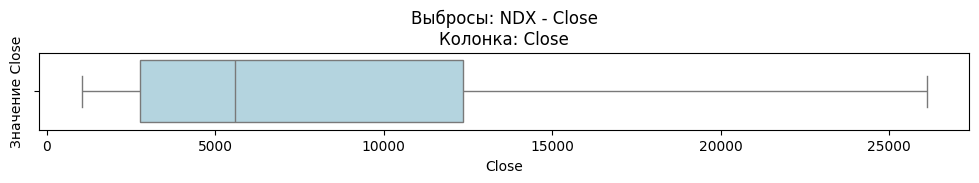

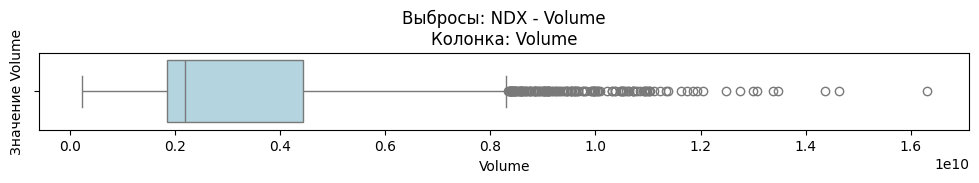

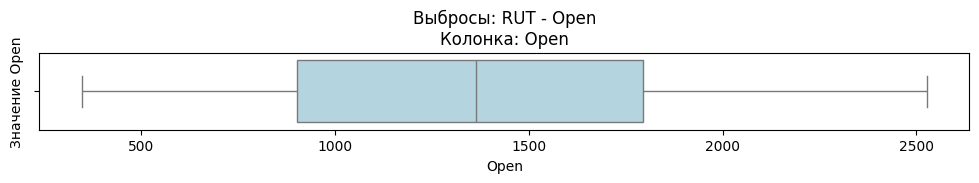

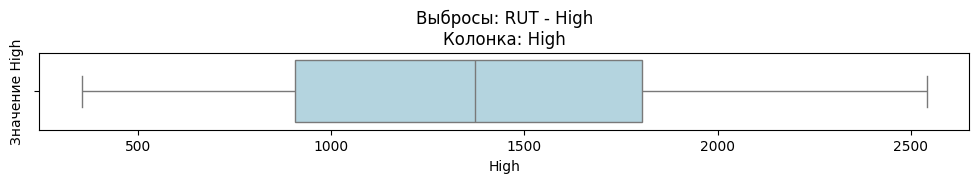

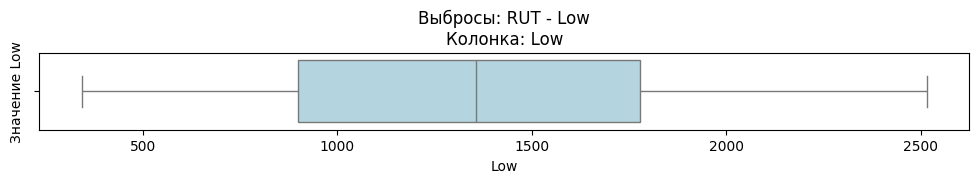

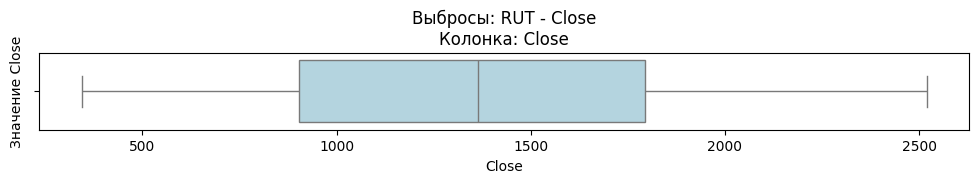

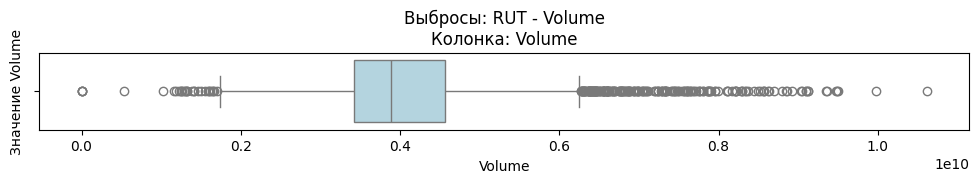

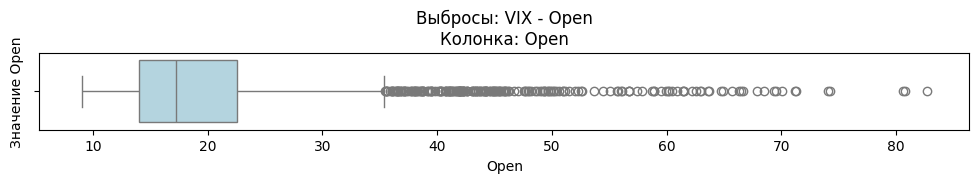

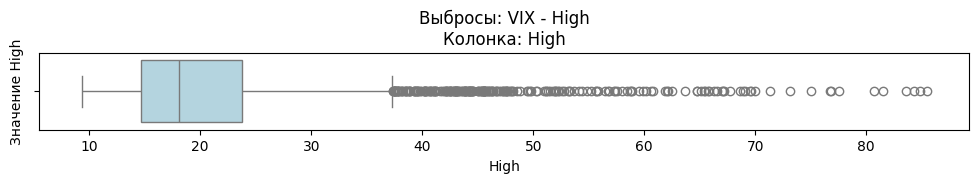

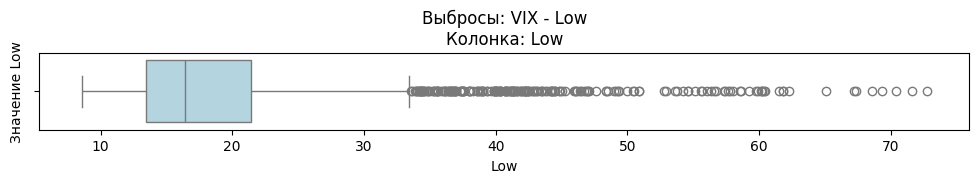

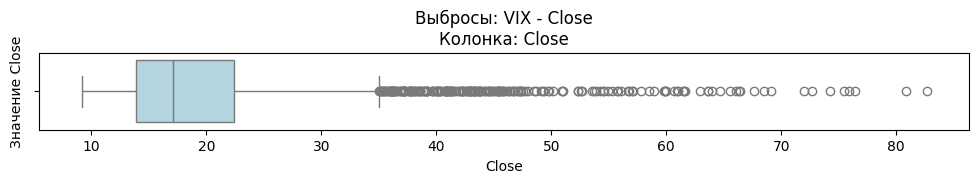

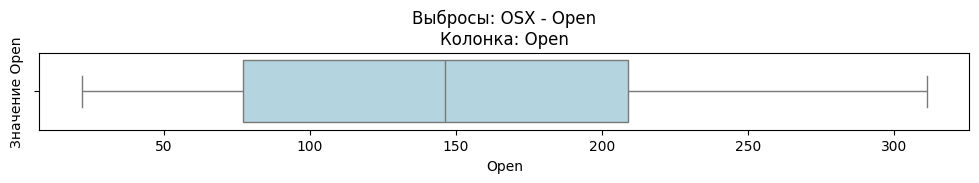

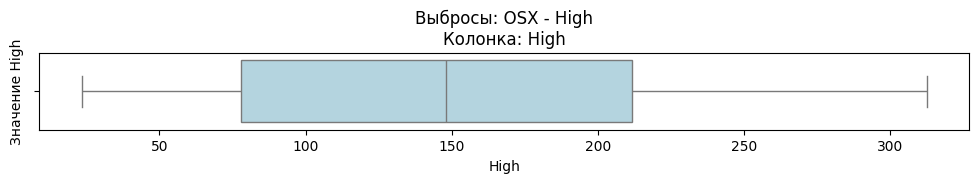

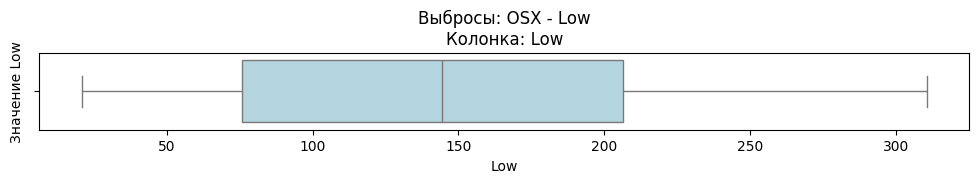

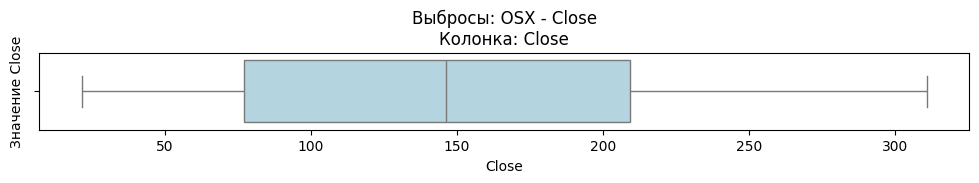

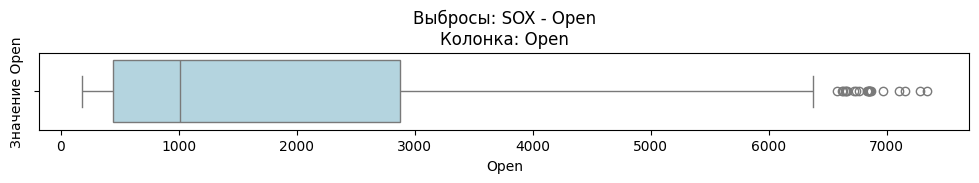

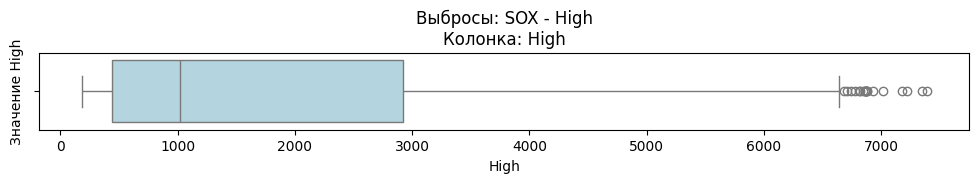

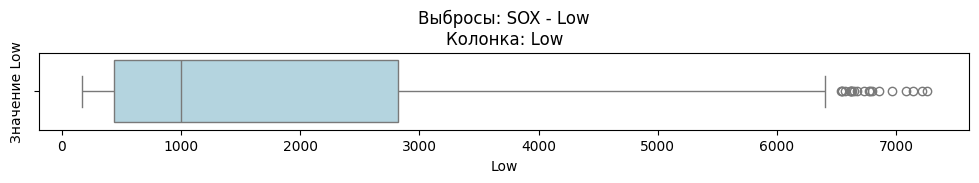

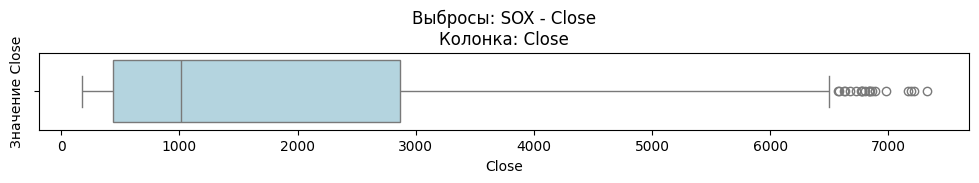

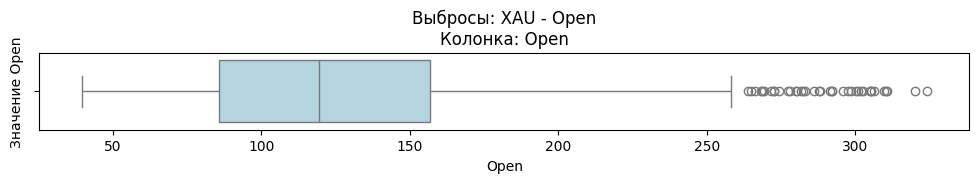

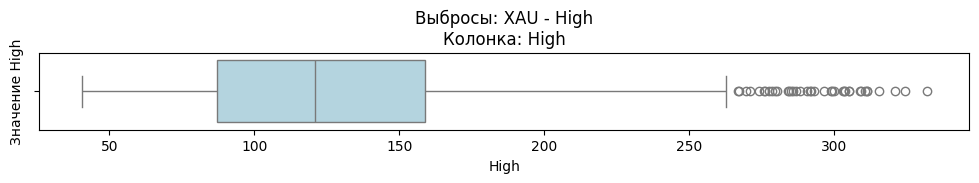

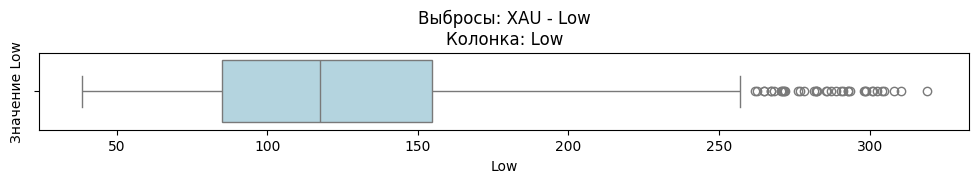

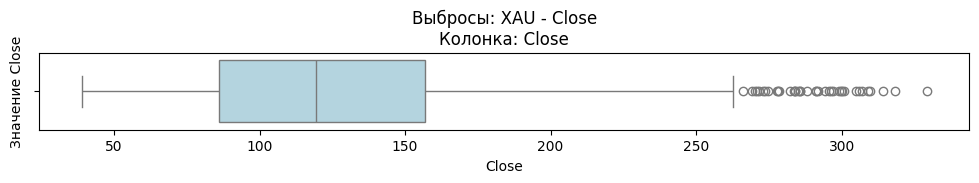

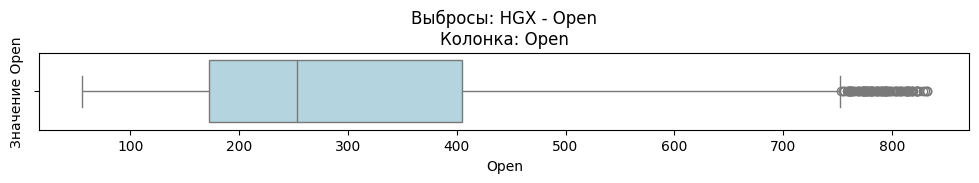

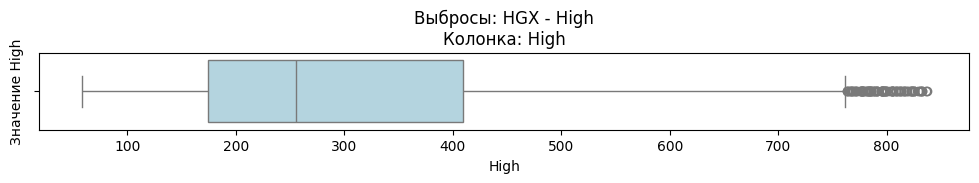

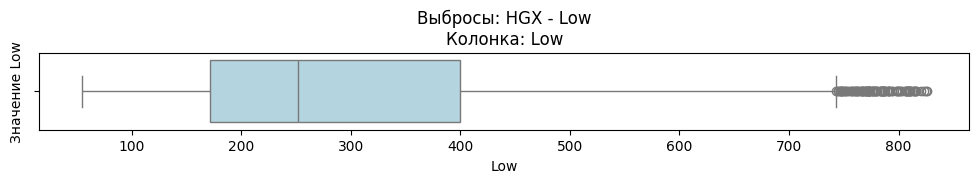

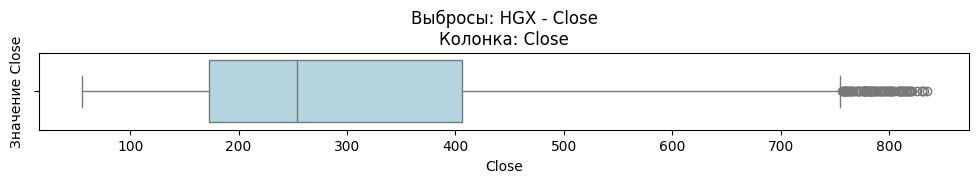

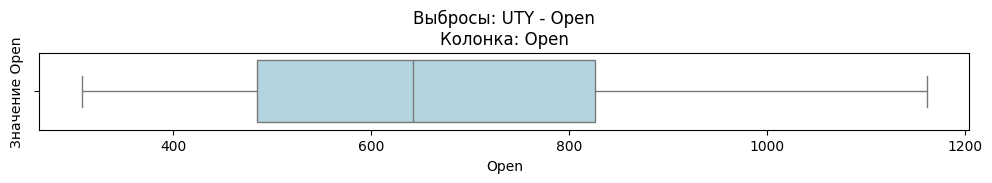

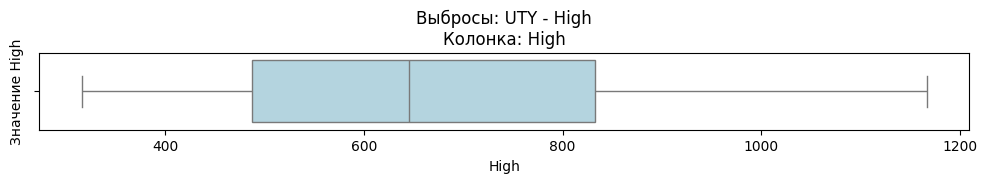

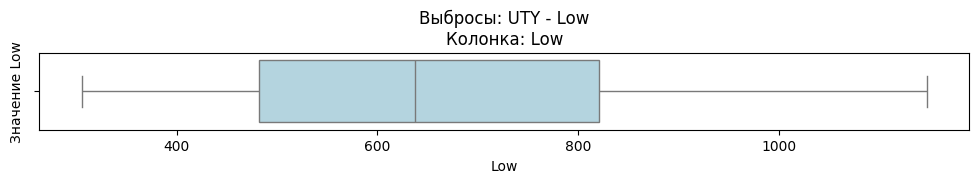

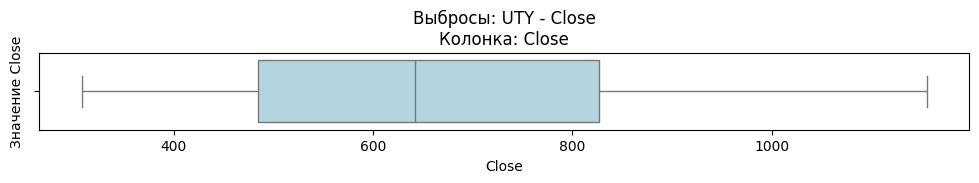

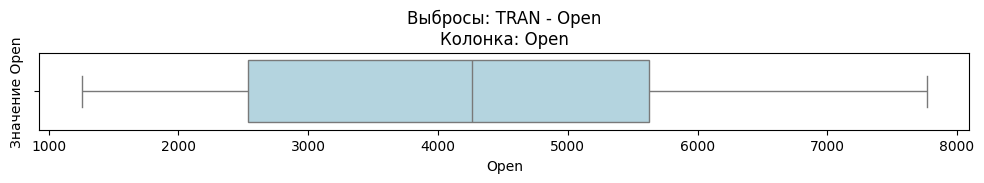

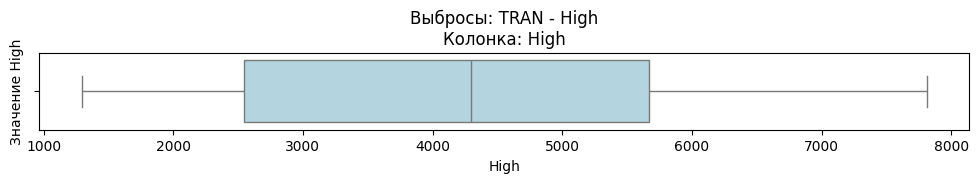

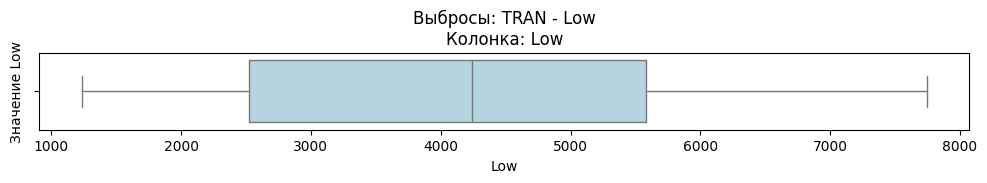

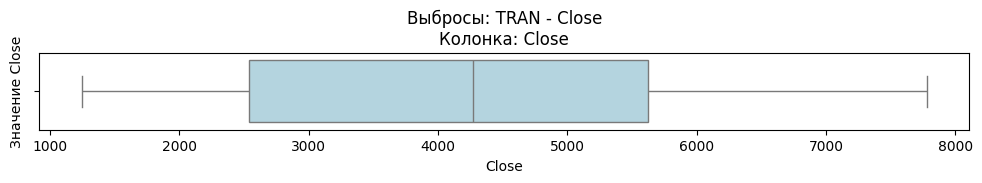

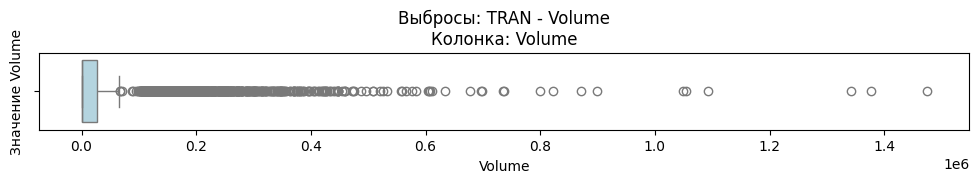

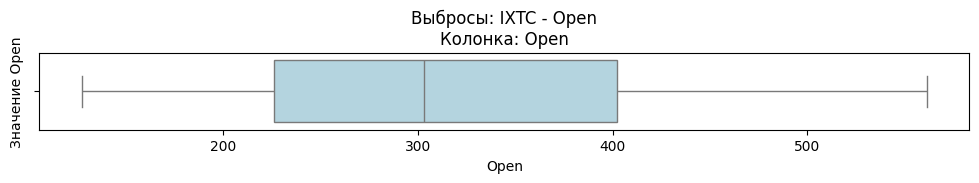

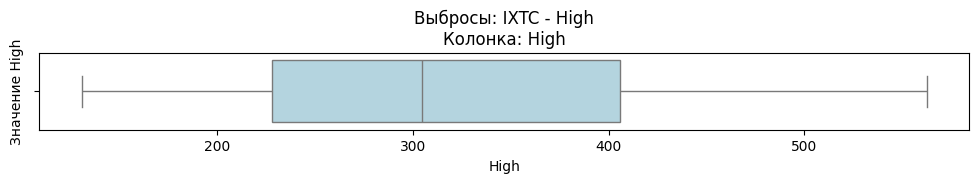

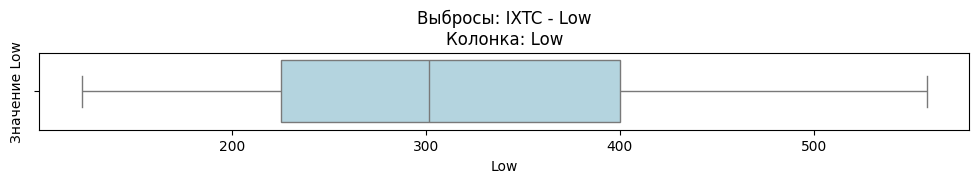

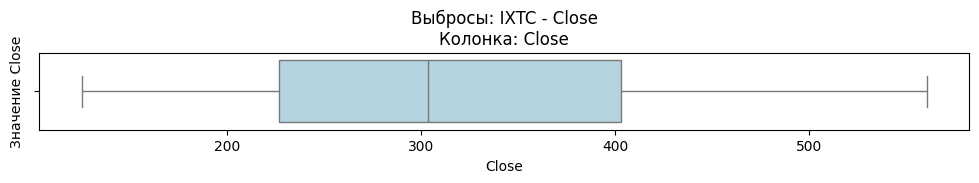

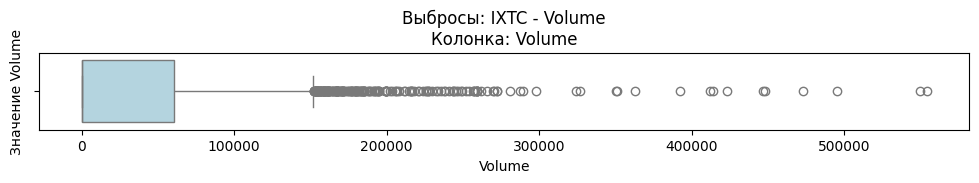

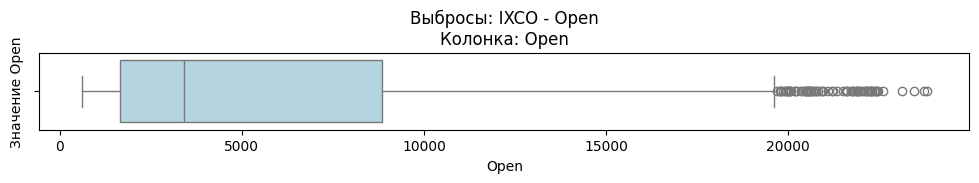

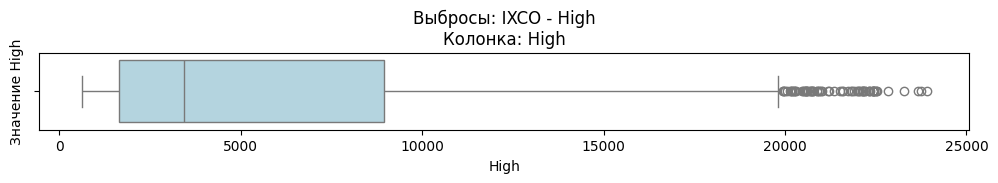

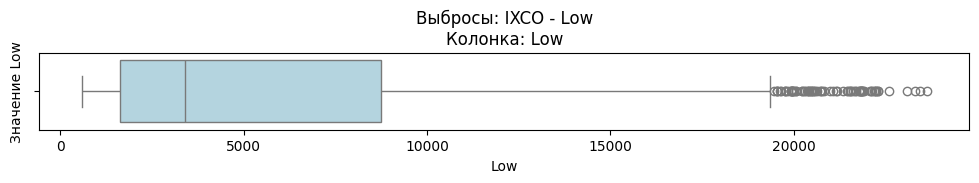

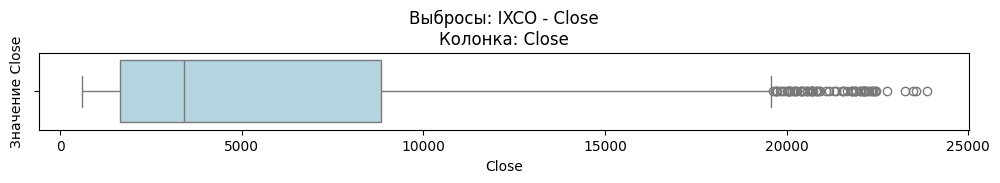

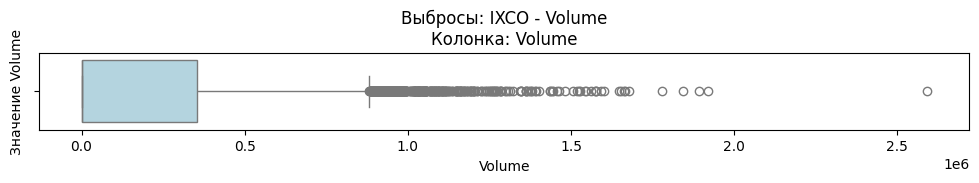

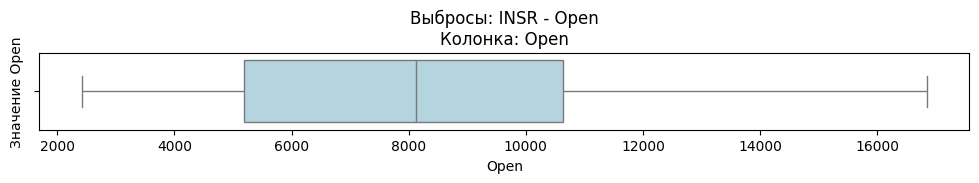

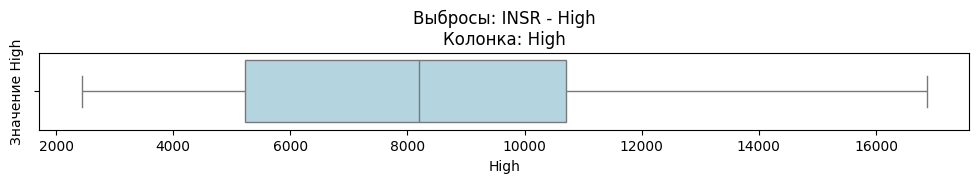

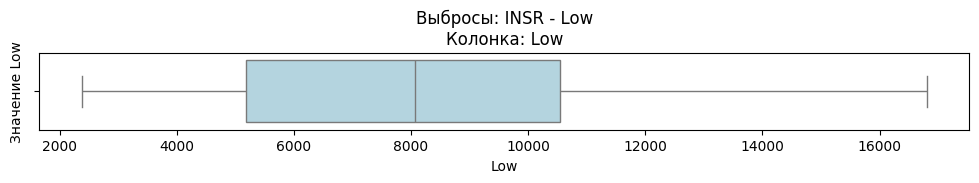

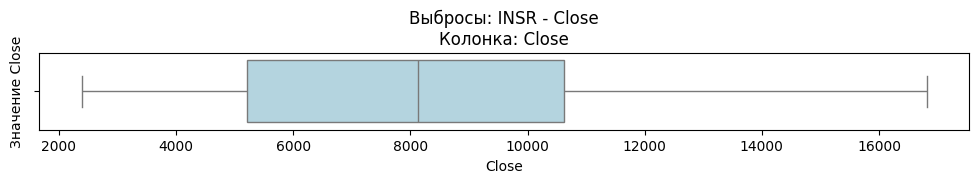

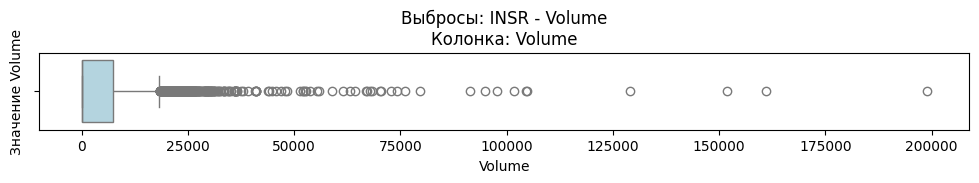

In [14]:
def plot_box(df,cat, col):
    df2 = df[df['Ticker'] == cat]
    plt.figure(figsize=(12,1))
    box_plot = sns.boxplot(x=df2[col], orient='h', color='lightblue', showfliers=True)
    plt.title(f'Выбросы: {cat} - {col}\nКолонка: {col}')
    plt.ylabel(f'Значение {col}')
    plt.show()

for arg in mass_out:
    plot_box(df, arg['tick'], arg['col'])

# Вывод
1. Выбросы данных присутствуют во всех числовых колонках, но их количество очень мало (меньше 1%), что допустимо. Возможно это какието сильные сигналы, которые в дальнейшем повлияют на модель
2. Приддетальном рассмотрении видно дни соседние с выбрасами очень близки по значению с ними, из чего можно сделать вывод, что на эти значения оказали влияние различные события в мире

In [15]:
df.sample(5)

,Date,Open,High,Low,Close,Volume,Ticker,Name
67500,2022-03-14 04:00:00+00:00,443.809998,447.109985,438.410004,439.250000,0,IXTC,NASDAQ Telecommunications
69397,2012-09-27 04:00:00+00:00,1669.949951,1695.500000,1664.989990,1692.040039,0,IXCO,NASDAQ Computer
3691,2023-07-05 04:00:00+00:00,4442.040039,4454.060059,4436.609863,4446.819824,3482620000,SPX,S&P 500
57576,2016-10-03 04:00:00+00:00,620.869995,620.869995,609.789978,613.900024,0,UTY,PHLX Utilities
76135,2022-07-13 04:00:00+00:00,10055.250000,10093.129883,9946.429688,10028.200195,14800,INSR,NASDAQ Insurance


### Для анализа возьмем данные за последние 5 лет (за 17 получается очень много прям жуть)

In [16]:
col_num = ['Open', 'High', 'Low', 'Close', 'Volume']
df_an = df[df['Date'].dt.year >= 2020].copy()
df_an['Year'] = df_an['Date'].dt.year

In [17]:
def year_statistics(df, years_range=range(2020, 2026)):
      
    yearly_comparison = {}
    
    for column in col_num:
        print(f"Cравнение {column} по годам:")
        pivot_stats = df.pivot_table(index=['Ticker', 'Name'],columns='Year',values=column, aggfunc=['mean', 'std']).round(2)
        
        pivot_stats.columns = [f"{year}_{stat}" for stat, year in pivot_stats.columns]
        
        display(pivot_stats)
        
        yearly_comparison[column] = pivot_stats
    
    return yearly_comparison

stat = year_statistics(df_an)


Cравнение Open по годам:


,,2020_mean,2021_mean,2022_mean,2023_mean,2024_mean,2025_mean,2020_std,2021_std,2022_std,2023_std,2024_std,2025_std
Ticker,Name,,,,,,,,,,,,
DJI,Dow Jones Industrial,26894.12,34039.09,32906.51,34106.54,40319.80,43612.26,2519.51,1622.64,1737.65,1155.27,2057.49,2056.50
HGX,PHLX Housing,339.25,468.77,405.61,507.62,725.28,676.91,56.48,32.72,36.61,60.08,57.04,46.80
INSR,NASDAQ Insurance,8883.50,10942.59,10891.97,11917.54,14712.13,15564.06,978.63,406.47,611.21,426.49,1148.80,356.78
IXCO,NASDAQ Computer,6965.07,10358.27,9331.14,10728.72,15783.89,18589.43,1093.07,1046.20,1144.36,1383.70,1461.01,2346.65
IXIC,NASDAQ Composite,10195.69,14371.28,12241.67,12957.82,17246.93,19943.78,1476.72,879.83,1340.47,1130.27,1373.83,1938.67
IXTC,NASDAQ Telecommunications,406.25,505.85,407.38,399.52,421.04,491.29,37.19,25.58,39.45,13.30,35.86,16.14
MID,S&P 400 Mid Cap,1879.73,2673.56,2498.01,2552.10,3001.17,3103.85,234.61,123.90,150.57,105.60,158.94,161.03
NDX,NASDAQ 100,10271.31,14485.10,12761.23,14176.55,19097.38,21996.25,1513.94,1139.42,1393.63,1520.92,1351.64,1973.39
OEX,S&P 100,1474.23,1955.59,1866.58,1981.15,2602.87,2992.76,148.24,140.09,147.74,138.68,203.08,236.93


Cравнение High по годам:


,,2020_mean,2021_mean,2022_mean,2023_mean,2024_mean,2025_mean,2020_std,2021_std,2022_std,2023_std,2024_std,2025_std
Ticker,Name,,,,,,,,,,,,
DJI,Dow Jones Industrial,27116.32,34210.67,33152.53,34271.17,40500.36,43863.70,2426.93,1599.44,1707.82,1146.60,2070.99,1978.12
HGX,PHLX Housing,343.22,473.03,410.49,512.28,731.00,683.54,55.66,32.35,36.48,60.30,57.19,46.10
INSR,NASDAQ Insurance,8970.55,11008.00,10983.60,11993.04,14793.67,15669.54,949.53,399.29,609.05,422.97,1151.49,351.29
IXCO,NASDAQ Computer,7040.15,10433.14,9447.69,10821.74,15905.74,18740.57,1078.99,1048.36,1149.31,1375.79,1465.01,2296.81
IXIC,NASDAQ Composite,10286.92,14455.26,12373.47,13048.33,17349.54,20080.16,1452.56,872.51,1343.86,1117.59,1375.57,1877.83
IXTC,NASDAQ Telecommunications,410.05,508.98,410.86,401.96,423.42,494.57,35.43,25.07,39.69,13.17,35.95,15.24
MID,S&P 400 Mid Cap,1896.53,2694.23,2523.21,2571.06,3021.86,3127.78,229.96,120.70,148.25,103.85,159.44,152.87
NDX,NASDAQ 100,10371.00,14575.41,12902.77,14280.95,19210.16,22145.11,1490.80,1136.58,1396.89,1507.66,1351.95,1904.70
OEX,S&P 100,1485.95,1965.61,1882.85,1992.52,2615.39,3010.38,143.85,139.71,146.76,137.17,203.51,229.17


Cравнение Low по годам:


,,2020_mean,2021_mean,2022_mean,2023_mean,2024_mean,2025_mean,2020_std,2021_std,2022_std,2023_std,2024_std,2025_std
Ticker,Name,,,,,,,,,,,,
DJI,Dow Jones Industrial,26654.45,33879.57,32625.37,33946.44,40131.48,43355.42,2624.88,1638.91,1741.35,1196.50,2046.99,2158.07
HGX,PHLX Housing,334.54,464.51,400.33,503.91,719.01,670.60,57.66,32.84,35.80,59.98,56.09,47.31
INSR,NASDAQ Insurance,8792.45,10872.35,10801.92,11844.96,14630.68,15450.55,1010.02,410.76,614.68,430.64,1133.35,366.33
IXCO,NASDAQ Computer,6888.78,10276.59,9203.37,10651.09,15649.97,18421.32,1095.88,1045.33,1120.95,1379.08,1445.91,2367.21
IXIC,NASDAQ Composite,10098.05,14270.96,12090.30,12876.66,17131.97,19789.14,1486.77,888.20,1314.40,1132.96,1362.70,1969.32
IXTC,NASDAQ Telecommunications,402.58,502.81,403.49,397.29,418.68,488.08,38.40,25.96,39.34,13.36,35.59,16.65
MID,S&P 400 Mid Cap,1859.88,2654.93,2469.10,2534.46,2983.00,3078.21,243.17,125.69,150.43,107.20,158.68,171.30
NDX,NASDAQ 100,10168.48,14384.05,12600.39,14086.03,18970.07,21832.56,1517.85,1143.19,1367.25,1521.91,1340.98,2011.02
OEX,S&P 100,1461.54,1946.04,1848.03,1971.03,2589.36,2973.30,152.52,140.64,146.39,139.88,201.69,242.57


Cравнение Close по годам:


,,2020_mean,2021_mean,2022_mean,2023_mean,2024_mean,2025_mean,2020_std,2021_std,2022_std,2023_std,2024_std,2025_std
Ticker,Name,,,,,,,,,,,,
DJI,Dow Jones Industrial,26890.67,34055.29,32897.35,34121.54,40323.13,43634.11,2521.70,1617.30,1729.26,1177.23,2053.08,2063.07
HGX,PHLX Housing,338.78,468.85,405.44,508.37,724.83,677.13,56.71,32.55,35.85,60.20,56.42,46.62
INSR,NASDAQ Insurance,8880.74,10938.84,10895.69,11920.57,14710.73,15561.32,978.46,407.18,611.46,426.74,1135.38,367.68
IXCO,NASDAQ Computer,6970.25,10362.55,9325.36,10744.30,15784.82,18598.17,1088.00,1048.36,1136.07,1375.65,1454.75,2332.65
IXIC,NASDAQ Composite,10201.51,14371.66,12231.35,12970.62,17247.47,19951.55,1471.25,880.73,1330.35,1122.55,1368.79,1922.14
IXTC,NASDAQ Telecommunications,406.58,505.97,407.06,399.75,421.03,491.38,36.91,25.52,39.50,13.10,35.74,16.00
MID,S&P 400 Mid Cap,1878.52,2675.53,2496.37,2553.50,3002.54,3104.36,236.85,122.55,149.04,106.31,158.53,161.25
NDX,NASDAQ 100,10279.14,14488.81,12751.08,14192.92,19096.98,22006.65,1506.43,1141.91,1384.56,1511.47,1346.63,1956.18
OEX,S&P 100,1474.48,1956.69,1865.66,1982.79,2603.25,2994.04,148.18,140.21,146.93,138.22,202.33,235.53


Cравнение Volume по годам:


,,2020_mean,2021_mean,2022_mean,2023_mean,2024_mean,2025_mean,2020_std,2021_std,2022_std,2023_std,2024_std,2025_std
Ticker,Name,,,,,,,,,,,,
DJI,Dow Jones Industrial,4.197132e+08,3.402996e+08,3.665836e+08,3.151330e+08,3.765602e+08,5.624279e+08,1.380877e+08,8.687335e+07,8.305749e+07,7.254865e+07,1.248281e+08,1.683135e+08
HGX,PHLX Housing,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
INSR,NASDAQ Insurance,1.716443e+04,2.573849e+04,1.846335e+04,1.162520e+04,7.944400e+02,0.000000e+00,1.816874e+04,1.495562e+04,1.523828e+04,6.288750e+03,2.672940e+03,0.000000e+00
IXCO,NASDAQ Computer,6.188411e+05,8.638151e+05,9.259845e+05,8.794220e+05,1.060036e+05,0.000000e+00,2.343321e+05,2.484000e+05,2.626225e+05,2.464089e+05,3.766260e+05,0.000000e+00
IXIC,NASDAQ Composite,4.012986e+09,5.124791e+09,4.964447e+09,4.970726e+09,5.827405e+09,9.345154e+09,9.809316e+08,1.351341e+09,7.631167e+08,8.019783e+08,1.276761e+09,6.123966e+09
IXTC,NASDAQ Telecommunications,1.153016e+05,1.211278e+05,1.440155e+05,1.285076e+05,1.380635e+04,0.000000e+00,5.765363e+04,4.827972e+04,7.152179e+04,4.306814e+04,5.537464e+04,0.000000e+00
MID,S&P 400 Mid Cap,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
NDX,NASDAQ 100,4.012986e+09,5.124791e+09,4.964447e+09,4.970726e+09,5.827405e+09,8.893052e+09,9.809316e+08,1.351341e+09,7.631167e+08,8.019783e+08,1.276761e+09,1.727368e+09
OEX,S&P 100,4.922448e+09,4.417140e+09,4.617723e+09,4.013729e+09,3.921145e+09,5.127467e+09,1.357556e+09,9.802612e+08,8.823697e+08,7.938671e+08,7.466041e+08,9.763336e+08


In [19]:
yearly_avg = df_an.groupby(['Year', 'Ticker', 'Name'])['Close'].agg(['mean', 'std', 'min', 'max']).reset_index()
yearly_avg

,Year,Ticker,Name,mean,std,min,max
0,2020,DJI,Dow Jones Industrial,26890.673612,2521.704585,18591.929688,30606.480469
1,2020,HGX,PHLX Housing,338.777748,56.714734,180.419998,410.450012
2,2020,INSR,NASDAQ Insurance,8880.744586,978.464908,6343.129883,10673.139648
3,2020,IXCO,NASDAQ Computer,6970.245542,1088.001536,4608.770020,8884.570312
4,2020,IXIC,NASDAQ Composite,10201.506435,1471.254251,6860.669922,12899.419922
5,2020,IXTC,NASDAQ Telecommunications,406.579605,36.911067,298.170013,474.130005
6,2020,MID,S&P 400 Mid Cap,1878.524390,236.846016,1218.550049,2315.360107
7,2020,NDX,NASDAQ 100,10279.140189,1506.427366,6994.290039,12888.280273
8,2020,OEX,S&P 100,1474.479997,148.180899,1040.000000,1720.500000
9,2020,OSX,PHLX Oil Service,39.067183,14.107411,21.469999,80.989998


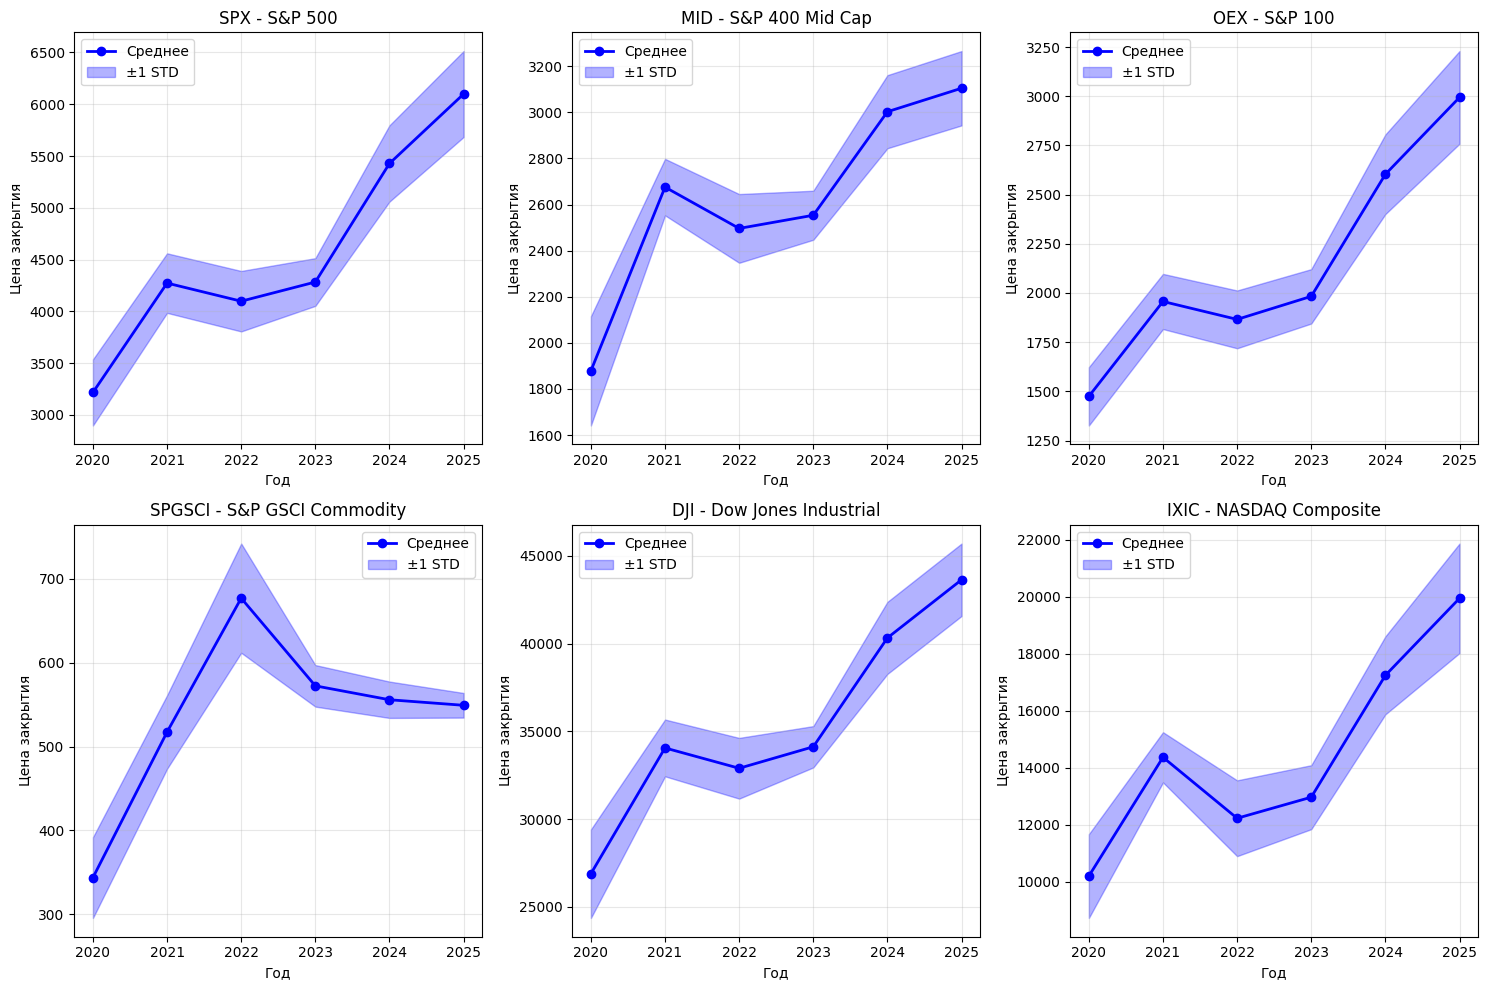

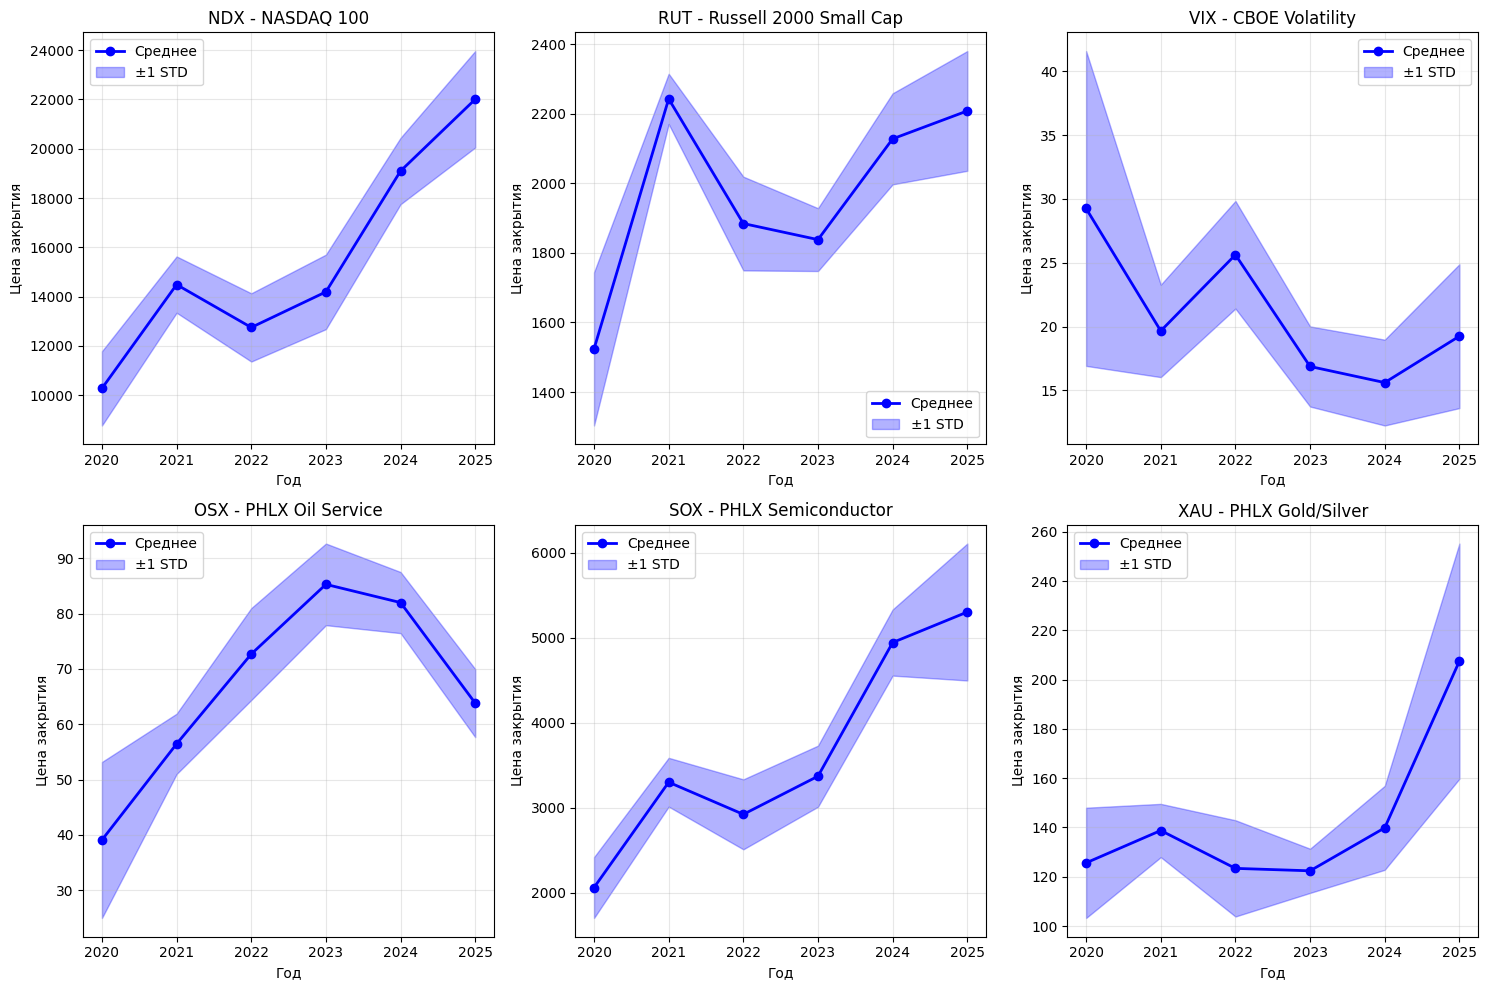

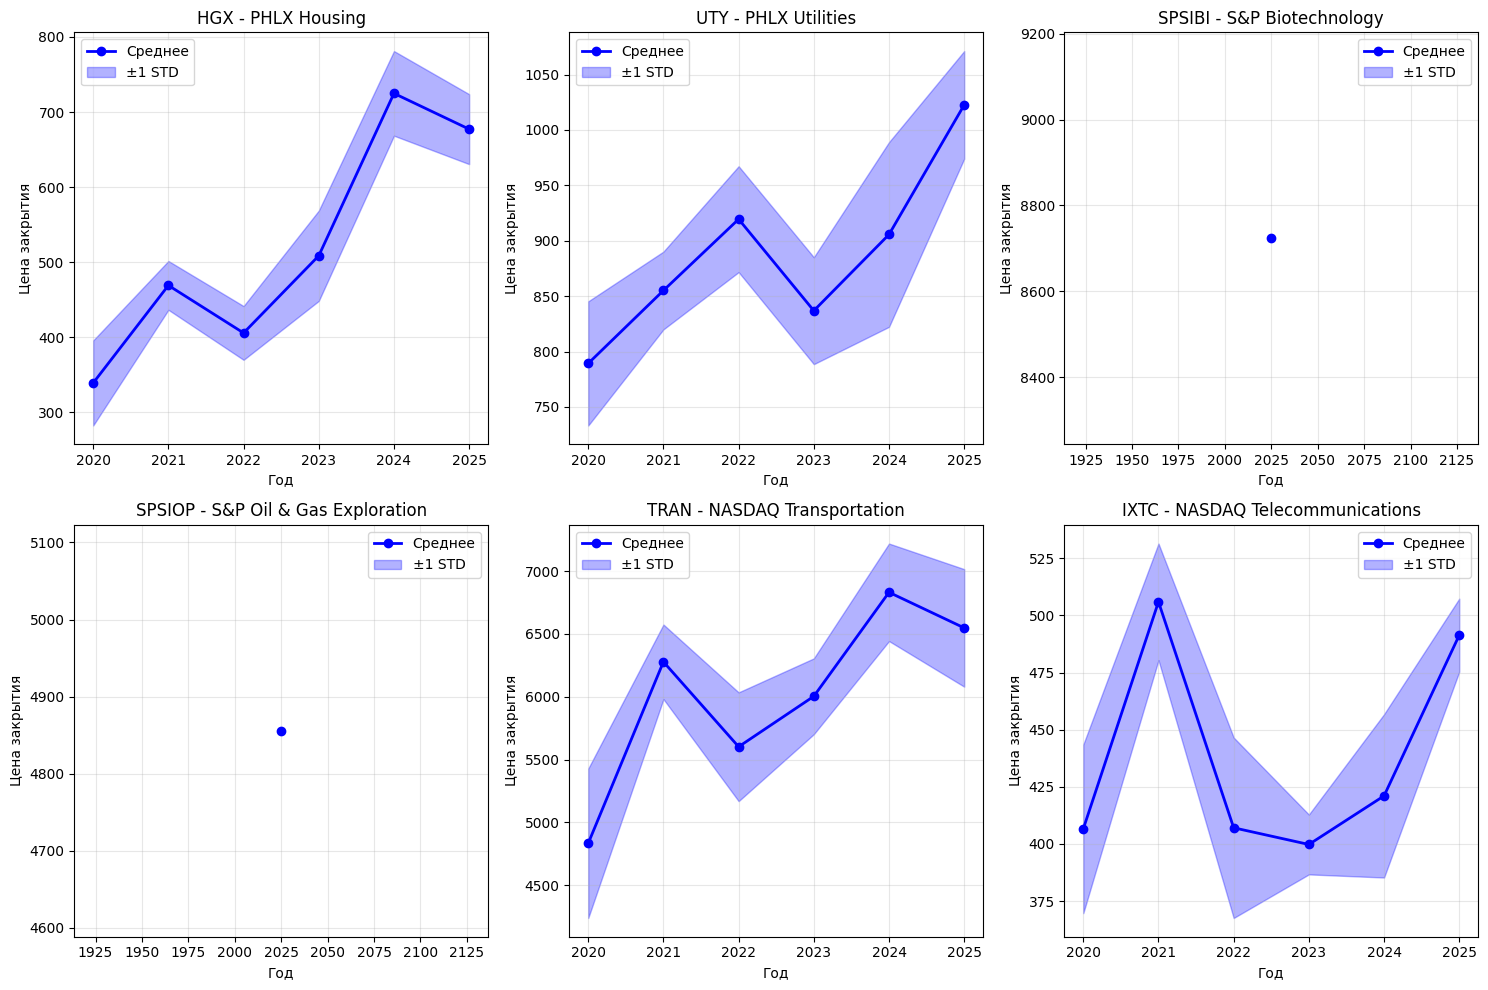

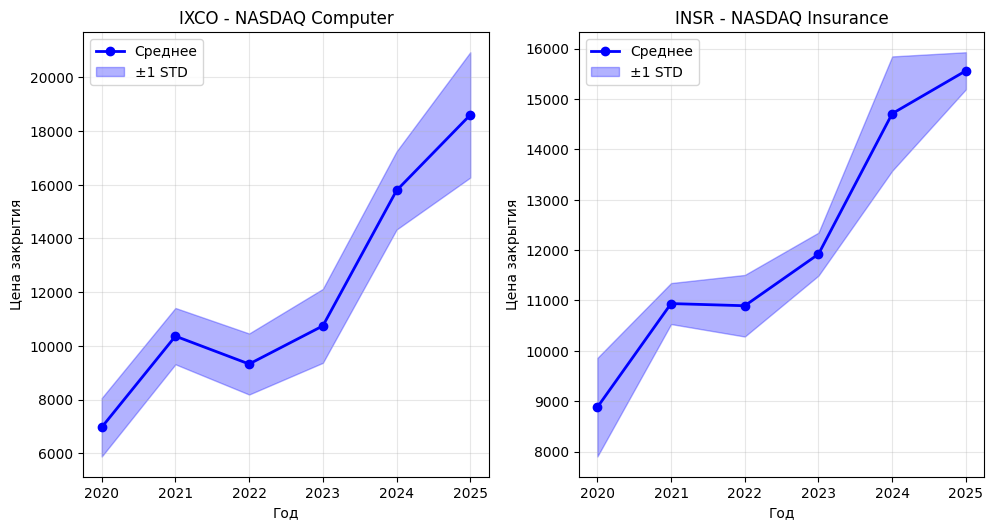

In [39]:
def plot_yearly_dynamics(data):

    yearly_avg = data.groupby(['Year', 'Ticker', 'Name'])['Close'].agg(['mean', 'std', 'min', 'max']).reset_index()
    
    unique_tickers = data['Ticker'].unique()
    
    
    for i in range(0, len(unique_tickers), 6):
        tickers_group = unique_tickers[i:i+6]
        group_data = yearly_avg[yearly_avg['Ticker'].isin(tickers_group)]    
        plt.figure(figsize=(15, 10))
        for j, ticker in enumerate(tickers_group):
            plt.subplot(2, 3, j+1)
            ticker_data = group_data[group_data['Ticker'] == ticker]
            name = ticker_data['Name'].iloc[0]
            
            # Линия средних значений
            plt.plot(ticker_data['Year'], ticker_data['mean'], 
                    marker='o', linewidth=2, label='Среднее', color='blue')
            
            # Область волатильности
            plt.fill_between(ticker_data['Year'],
                           ticker_data['mean'] - ticker_data['std'],
                           ticker_data['mean'] + ticker_data['std'],
                           alpha=0.3, color='blue', label='±1 STD')
            
            plt.title(f'{ticker} - {name}')
            plt.xlabel('Год')
            plt.ylabel('Цена закрытия')
            plt.grid(True, alpha=0.3)
            plt.legend()
        
        plt.tight_layout()
        plt.show()

plot_yearly_dynamics(df_an)

C:\Users\igorg\AppData\Local\Temp\ipykernel_9460\3296725700.py:9: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  yearly_pct_change = yearly_close.pct_change(axis=1) * 100


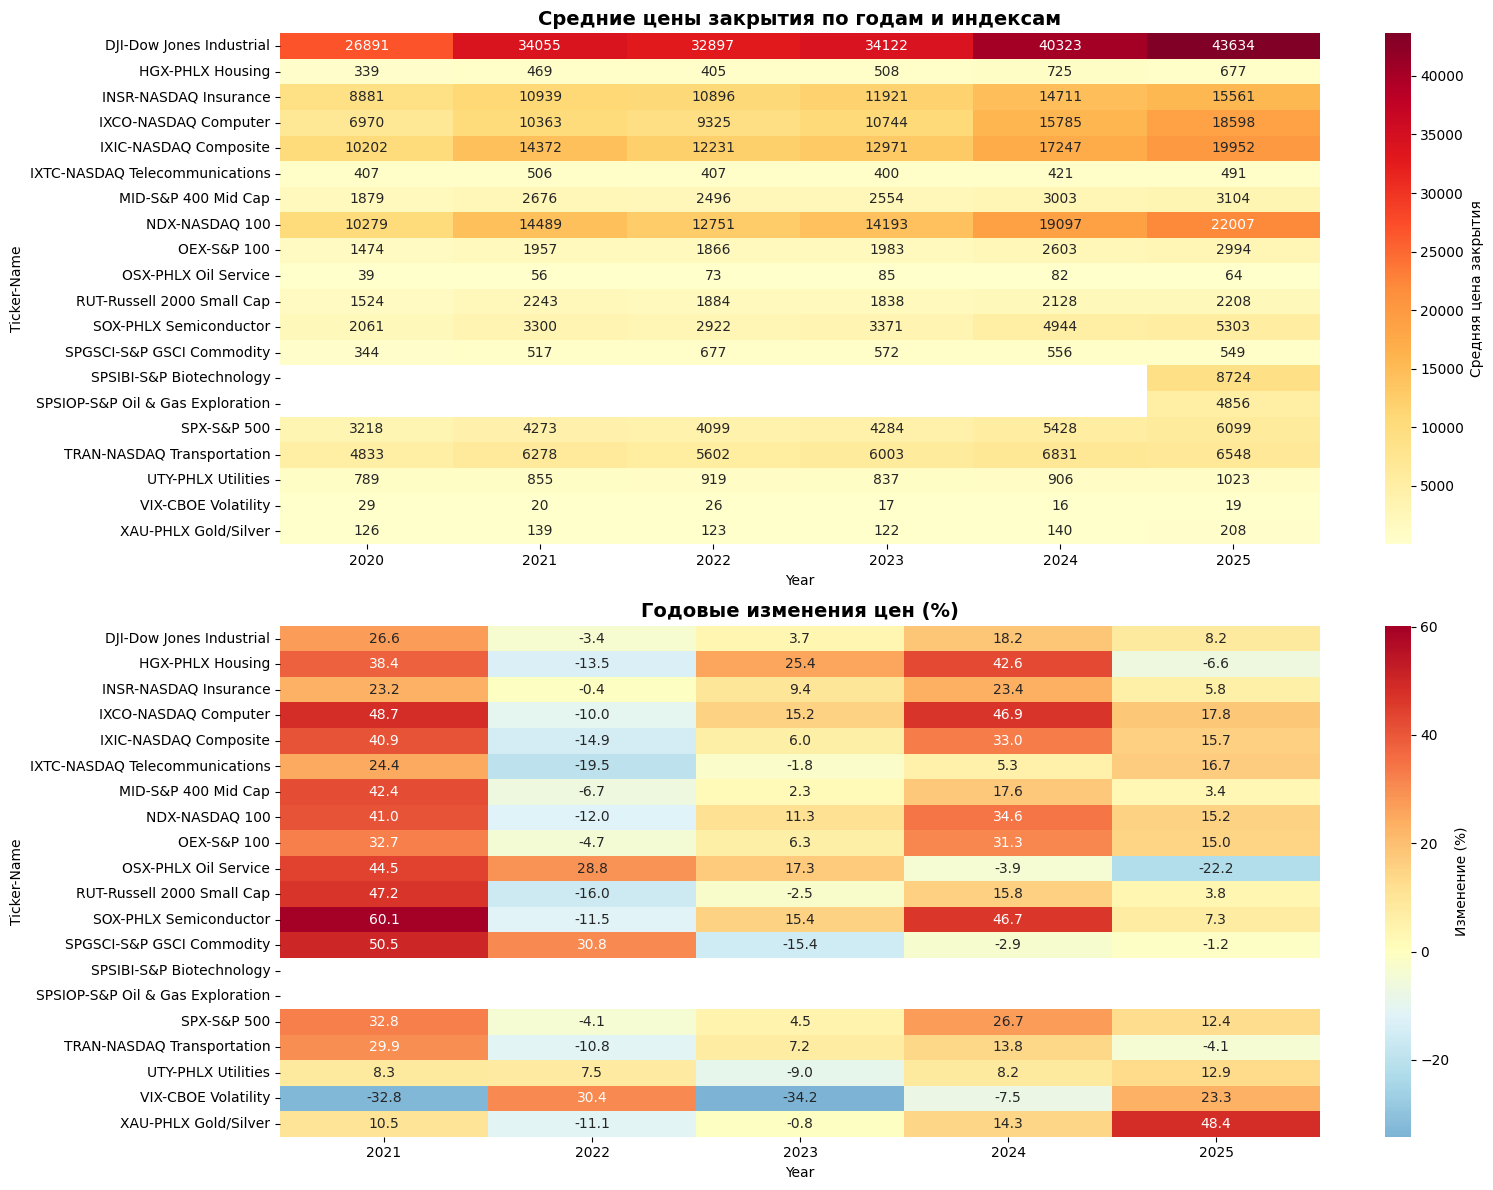

In [22]:
def create_yearly_heatmaps(data):
    yearly_close = data.pivot_table(
        index=['Ticker', 'Name'],
        columns='Year',
        values='Close',
        aggfunc='mean'
    )

    yearly_pct_change = yearly_close.pct_change(axis=1) * 100
    
    plt.figure(figsize=(16, 12))
    
    plt.subplot(2, 1, 1)
    sns.heatmap(yearly_close, annot=True, fmt='.0f', cmap='YlOrRd',
                cbar_kws={'label': 'Средняя цена закрытия'})
    plt.title('Средние цены закрытия по годам и индексам', fontsize=14, fontweight='bold')
    
    plt.subplot(2, 1, 2)
    sns.heatmap(yearly_pct_change.iloc[:, 1:], annot=True, fmt='.1f', cmap='RdYlBu_r',
                center=0, cbar_kws={'label': 'Изменение (%)'})
    plt.title('Годовые изменения цен (%)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return yearly_close, yearly_pct_change

yearly_close, yearly_pct_change = create_yearly_heatmaps(df_an)

АНАЛИЗ ТЕНДЕНЦИЙ ВОЛАТИЛЬНОСТИ:
ВОЛАТИЛЬНОСТЬ ПО ГОДАМ:
Year                                 2020     2021     2022     2023     2024  \
Ticker Name                                                                     
DJI    Dow Jones Industrial       2521.70  1617.30  1729.26  1177.23  2053.08   
HGX    PHLX Housing                 56.71    32.55    35.85    60.20    56.42   
INSR   NASDAQ Insurance            978.46   407.18   611.46   426.74  1135.38   
IXCO   NASDAQ Computer            1088.00  1048.36  1136.07  1375.65  1454.75   
IXIC   NASDAQ Composite           1471.25   880.73  1330.35  1122.55  1368.79   
IXTC   NASDAQ Telecommunications    36.91    25.52    39.50    13.10    35.74   
MID    S&P 400 Mid Cap             236.85   122.55   149.04   106.31   158.53   
NDX    NASDAQ 100                 1506.43  1141.91  1384.56  1511.47  1346.63   
OEX    S&P 100                     148.18   140.21   146.93   138.22   202.33   
OSX    PHLX Oil Service             14.11     5.46   

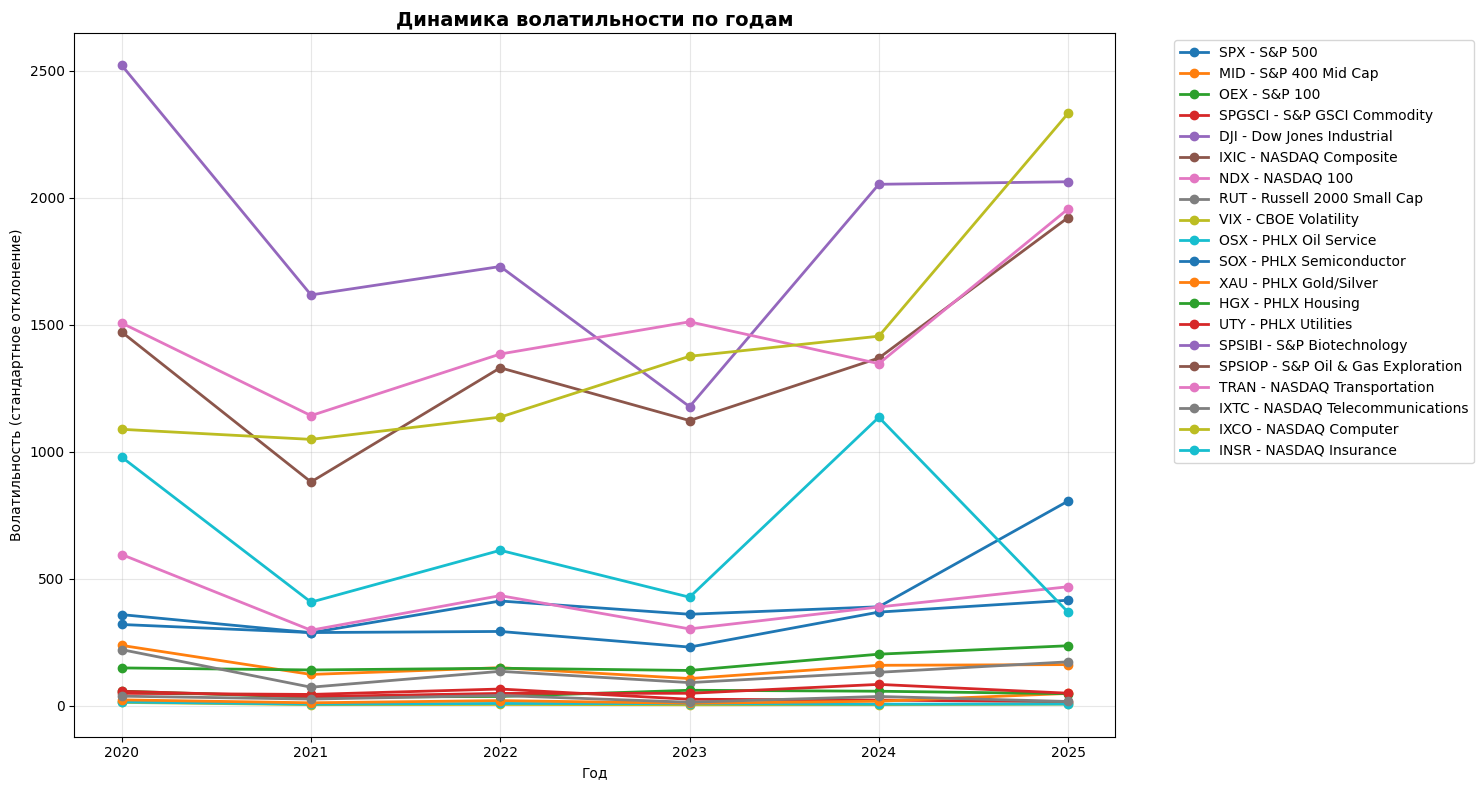

In [23]:
def analyze_volatility_trends(data):
    volatility_by_year = data.groupby(['Year', 'Ticker', 'Name'])['Close'].std().reset_index()
    volatility_by_year.rename(columns={'Close': 'Volatility'}, inplace=True)
    volatility_pivot = volatility_by_year.pivot_table(
        index=['Ticker', 'Name'],
        columns='Year',
        values='Volatility'
    ).round(2)
    
    print("ВОЛАТИЛЬНОСТЬ ПО ГОДАМ:")
    print(volatility_pivot)
    plt.figure(figsize=(15, 8))
    sample_tickers = data['Ticker'].unique()
    sample_data = volatility_by_year[volatility_by_year['Ticker'].isin(sample_tickers)]
    
    for ticker in sample_tickers:
        ticker_data = sample_data[sample_data['Ticker'] == ticker]
        name = ticker_data['Name'].iloc[0]
        plt.plot(ticker_data['Year'], ticker_data['Volatility'], 
                marker='o', linewidth=2, label=f'{ticker} - {name}')
    
    plt.title('Динамика волатильности по годам', fontsize=14, fontweight='bold')
    plt.xlabel('Год')
    plt.ylabel('Волатильность (стандартное отклонение)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return volatility_pivot

print("АНАЛИЗ ТЕНДЕНЦИЙ ВОЛАТИЛЬНОСТИ:")
volatility_trends = analyze_volatility_trends(df_an)

ГОДОВАЯ ДОХОДНОСТЬ ИНДЕКСОВ (%):
Year                               2020   2021   2022   2023   2024   2025
Ticker Name                                                               
DJI    Dow Jones Industrial        6.02  20.23  -9.40  13.74  12.80  12.10
HGX    PHLX Housing               12.31  38.43 -22.21  61.51   5.63   1.16
INSR   NASDAQ Insurance            0.42  15.70   1.94   8.21  23.36  -5.51
IXCO   NASDAQ Computer            46.95  40.19 -36.26  68.04  39.92  32.27
IXIC   NASDAQ Composite           41.75  23.20 -33.89  44.52  30.78  22.30
IXTC   NASDAQ Telecommunications  20.92   7.21 -25.23  11.57  11.04   6.03
MID    S&P 400 Mid Cap            11.69  25.23 -14.75  15.00  12.58   3.61
NDX    NASDAQ 100                 45.27  28.56 -33.71  54.90  27.01  22.69
OEX    S&P 100                    17.99  29.33 -22.99  31.39  30.10  19.31
OSX    PHLX Oil Service          -43.75  17.39  49.03   4.58 -13.01  -5.05
RUT    Russell 2000 Small Cap     18.48  15.39 -22.50  15.78  10.80

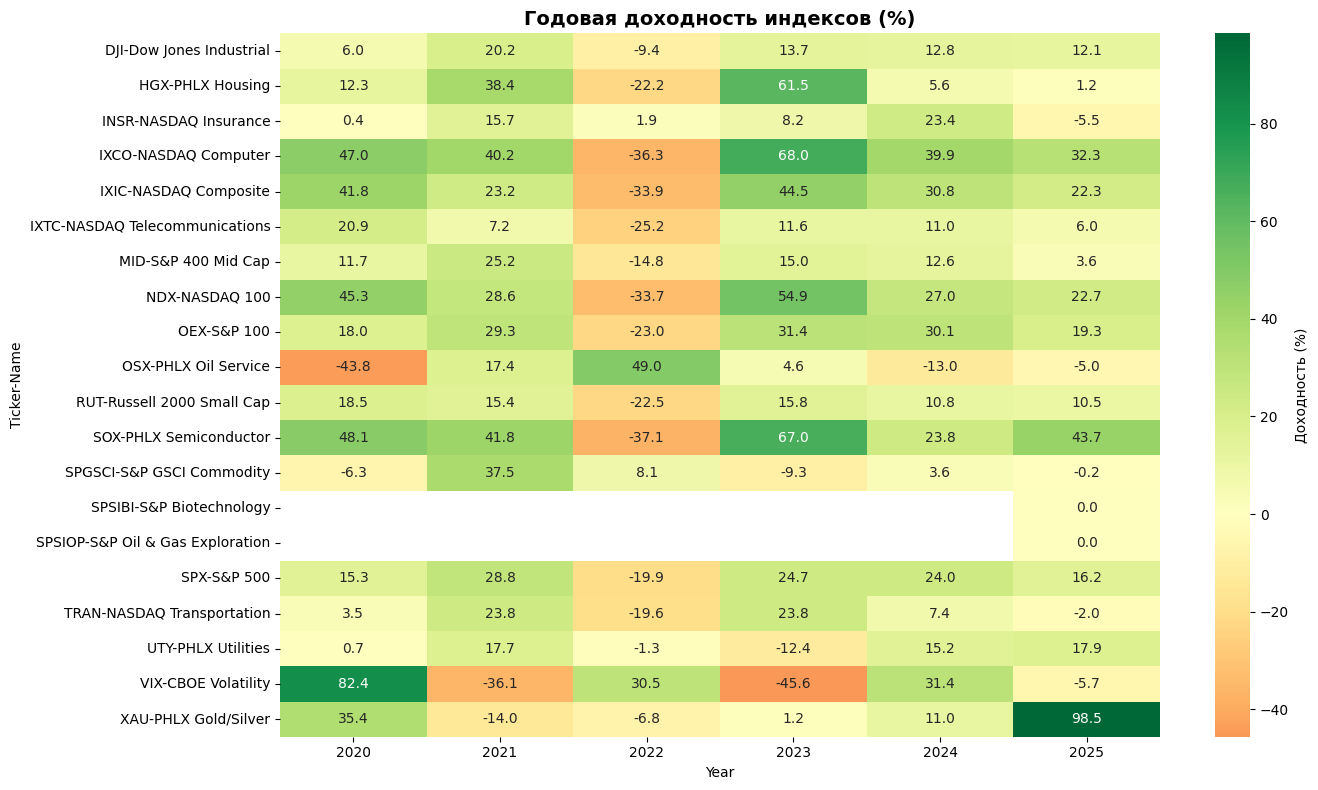

In [36]:
def calculate_annual_returns(data):
    yearly_prices = data.groupby(['Year', 'Ticker', 'Name'])['Close'].agg([
        'first', 'last', 'count'
    ]).reset_index()
    yearly_prices['Annual_Return_Pct'] = (
        (yearly_prices['last'] - yearly_prices['first']) / yearly_prices['first'] * 100
    ).round(2)
    returns_pivot = yearly_prices.pivot_table(
        index=['Ticker', 'Name'],
        columns='Year',
        values='Annual_Return_Pct'
    )
    
    print("ГОДОВАЯ ДОХОДНОСТЬ ИНДЕКСОВ (%):")
    print(returns_pivot)
    plt.figure(figsize=(14, 8))
    sns.heatmap(returns_pivot, annot=True, fmt='.1f', cmap='RdYlGn',
                center=0, cbar_kws={'label': 'Доходность (%)'})
    plt.title('Годовая доходность индексов (%)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    avg_returns = returns_pivot.mean(axis=1).sort_values(ascending=False)
    
    return returns_pivot, avg_returns

annual_returns, avg_returns = calculate_annual_returns(df_an)

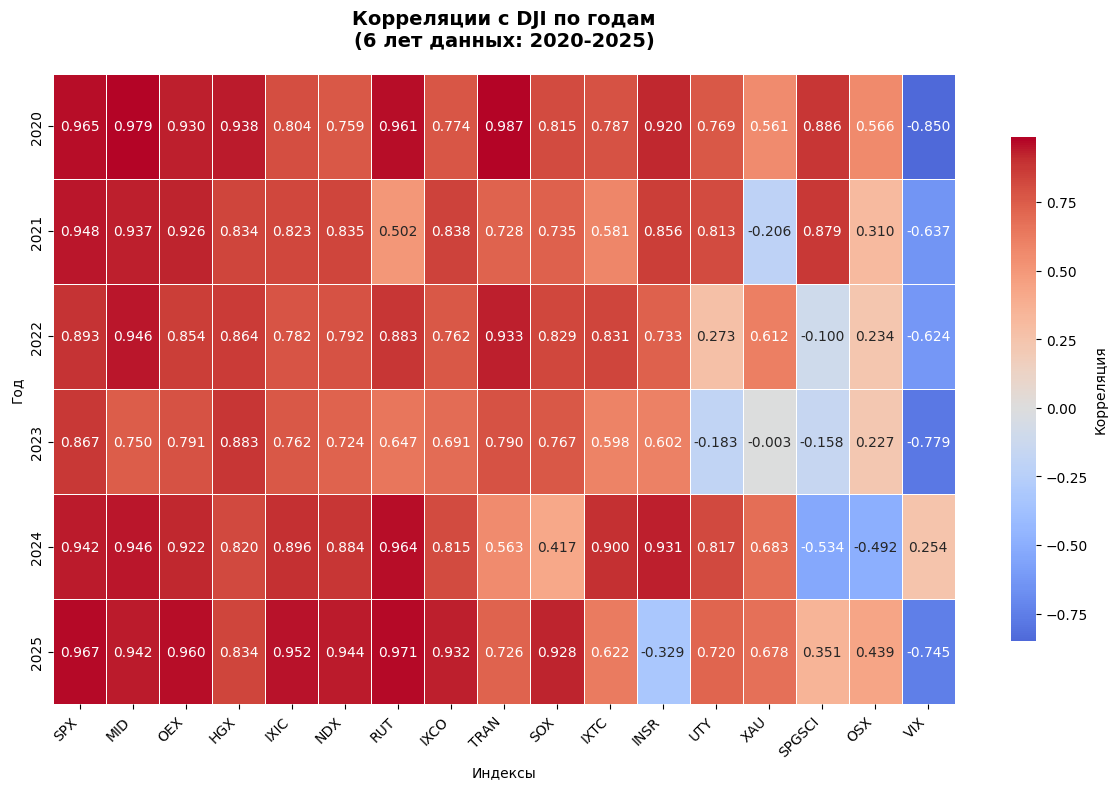

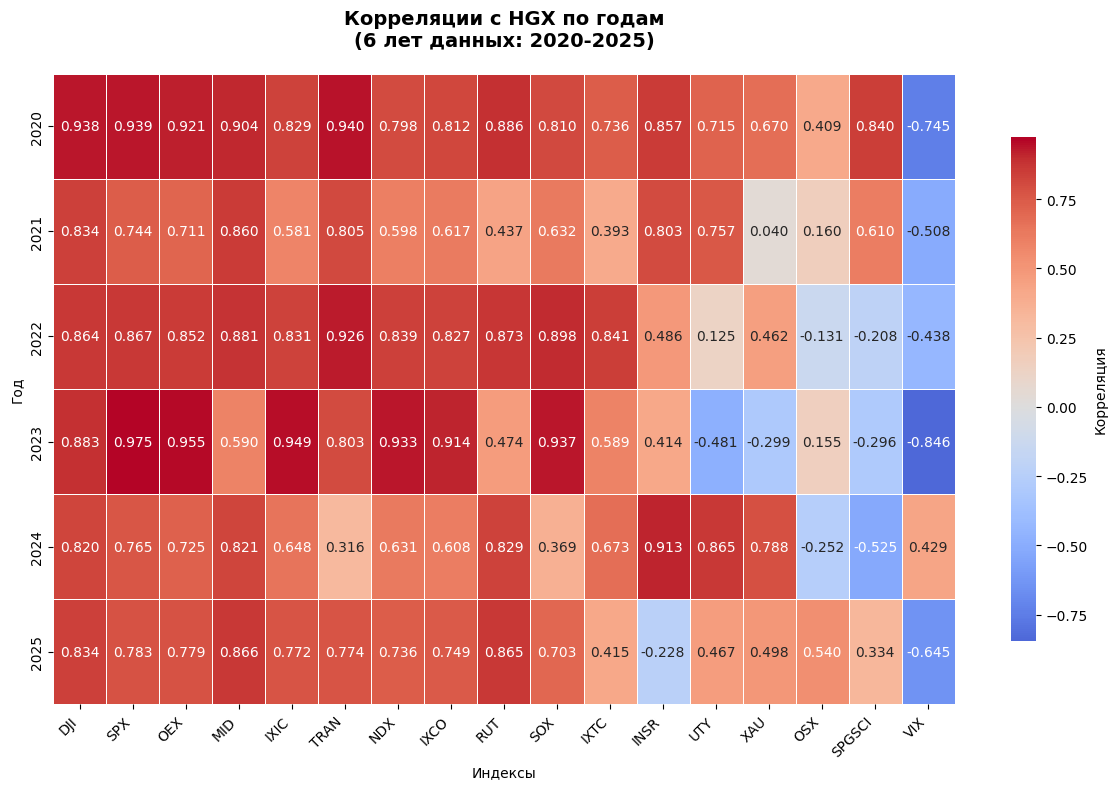

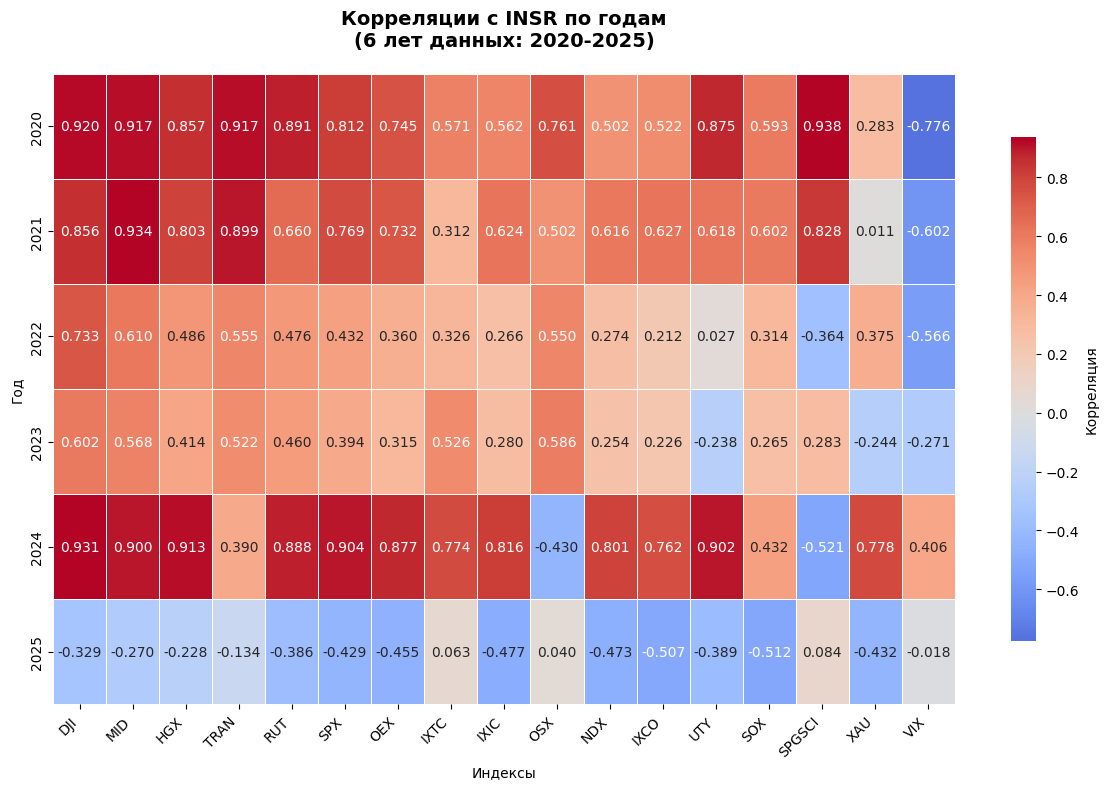

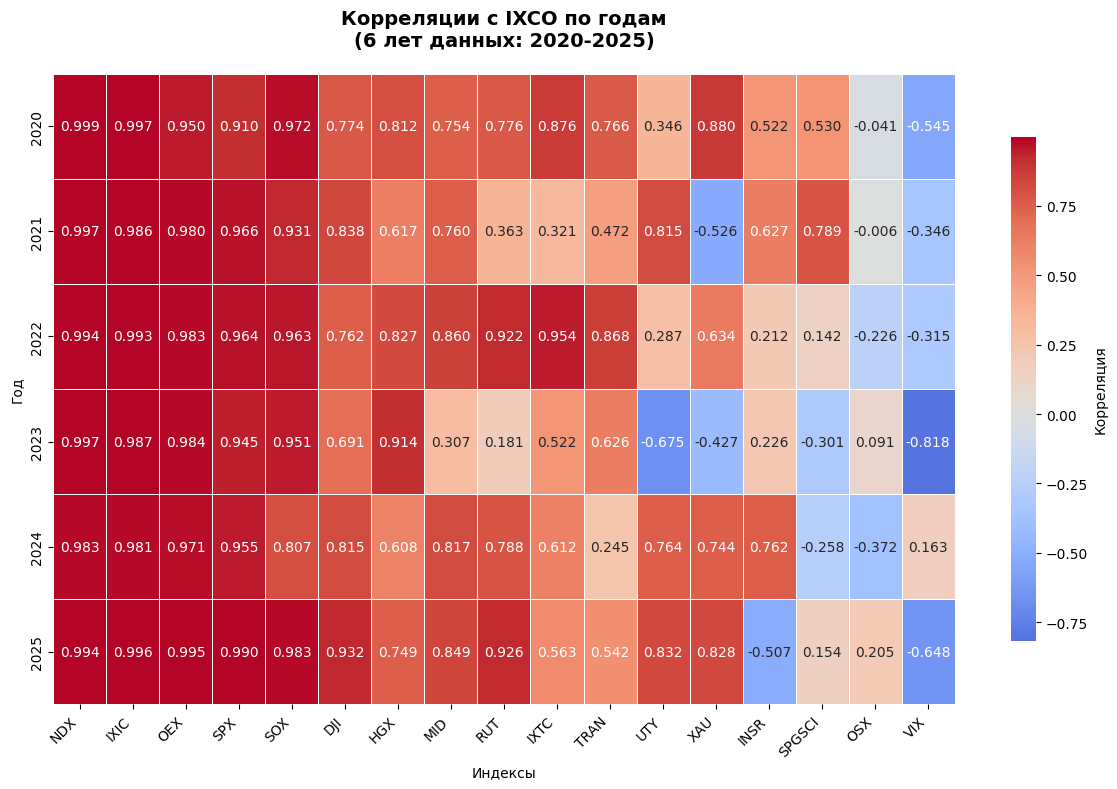

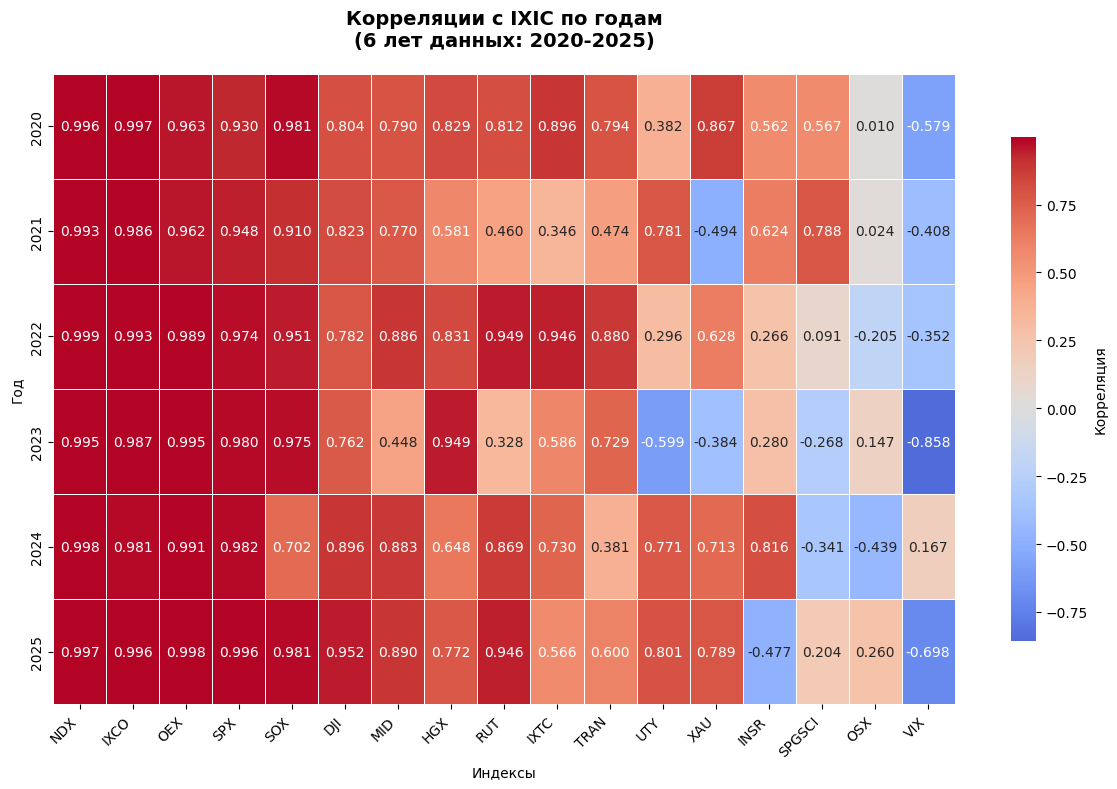

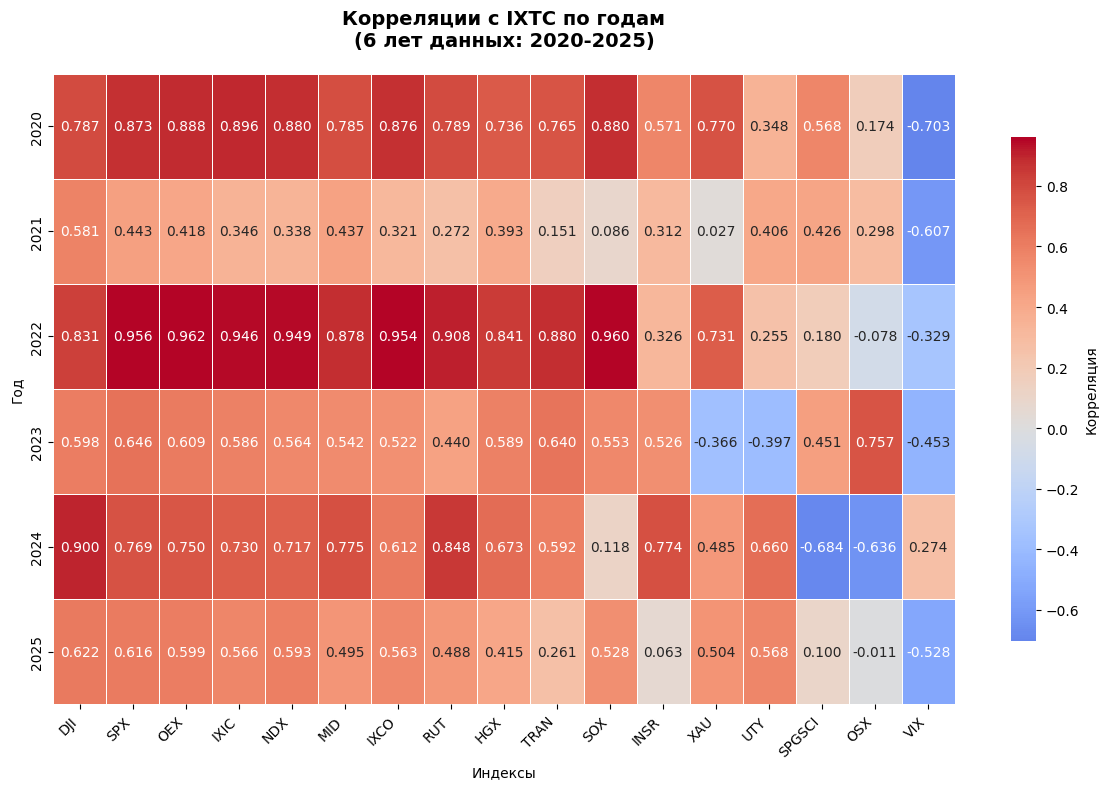

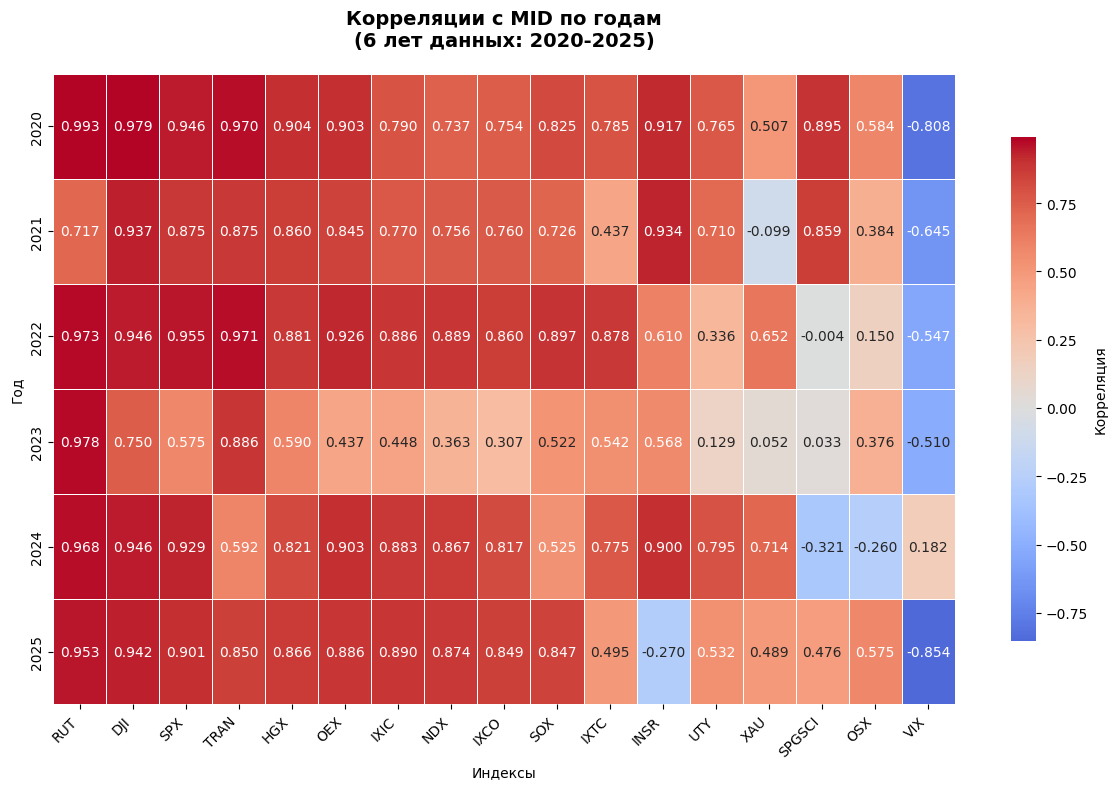

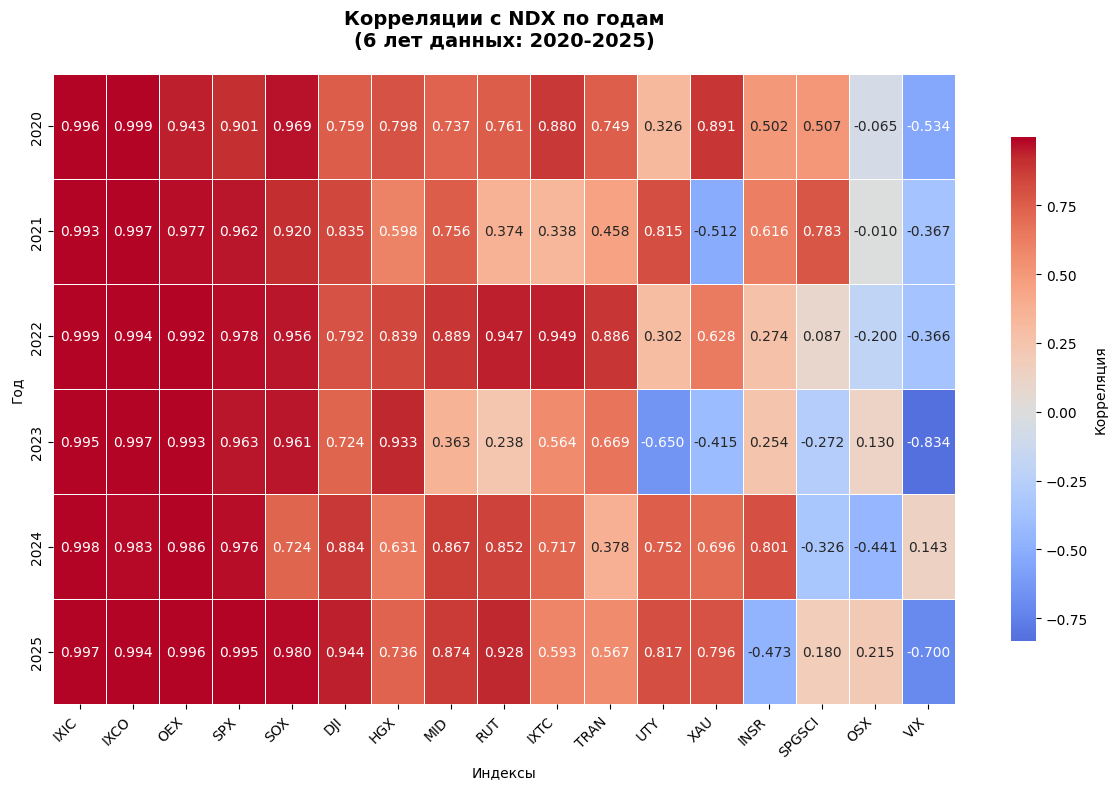

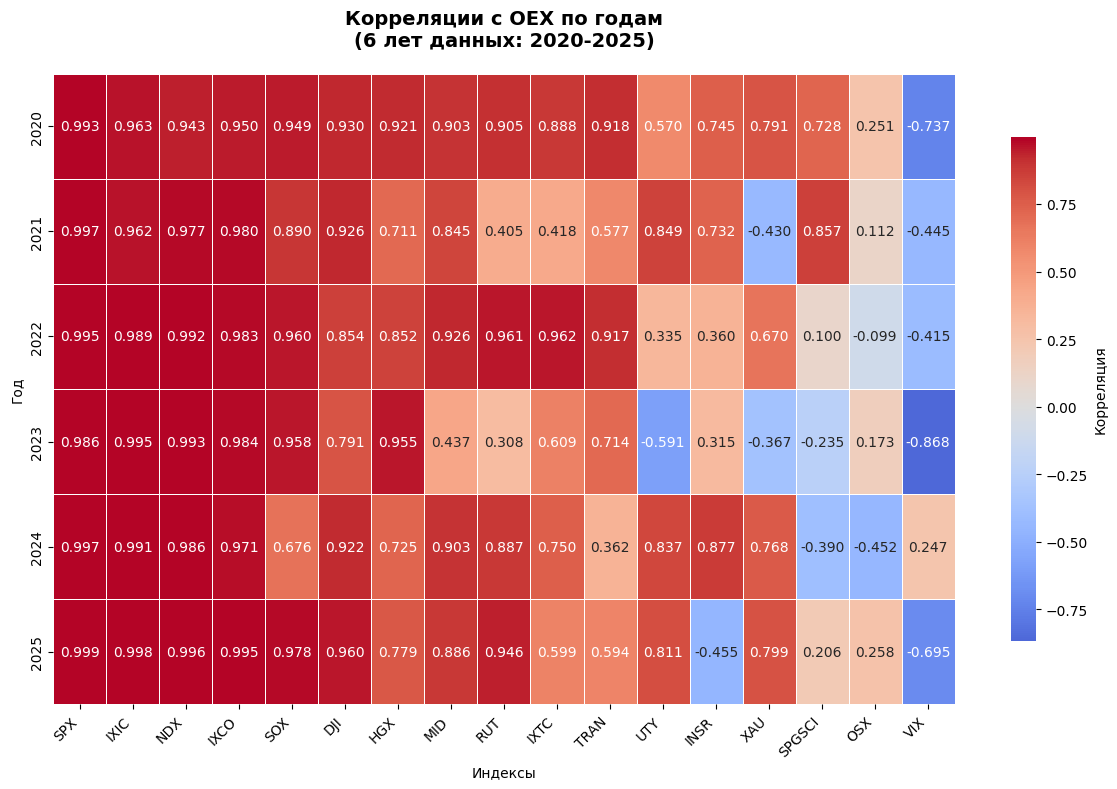

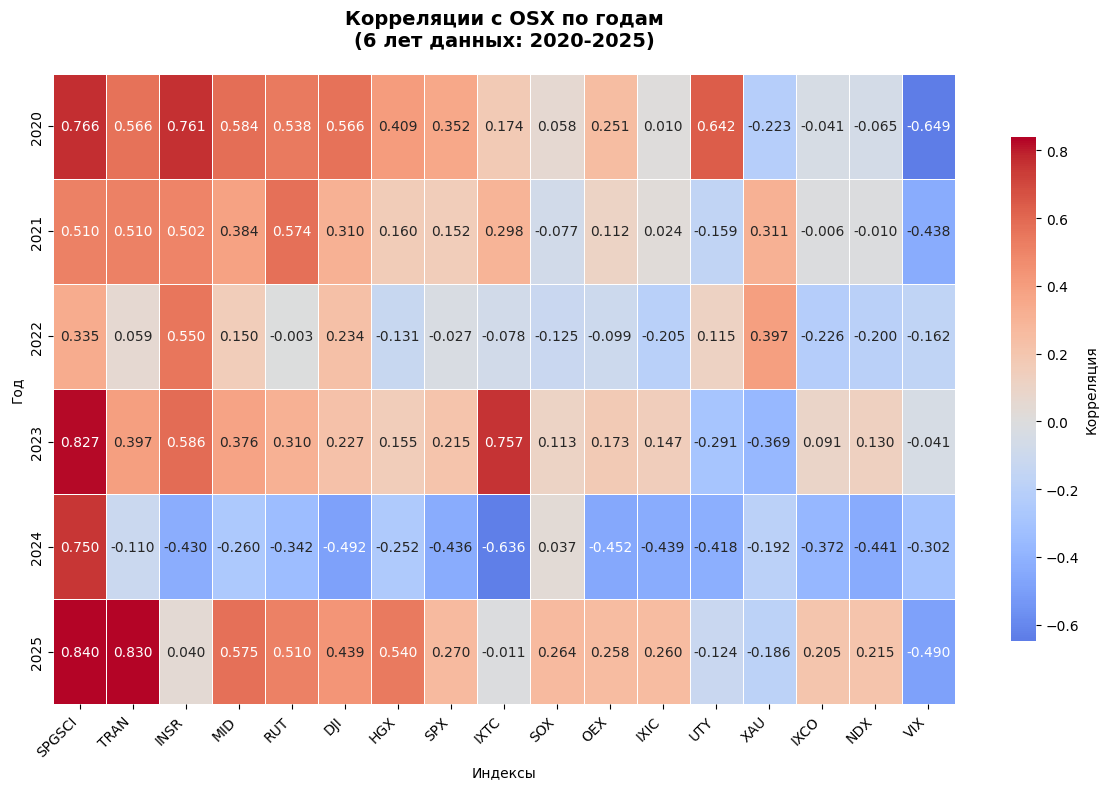

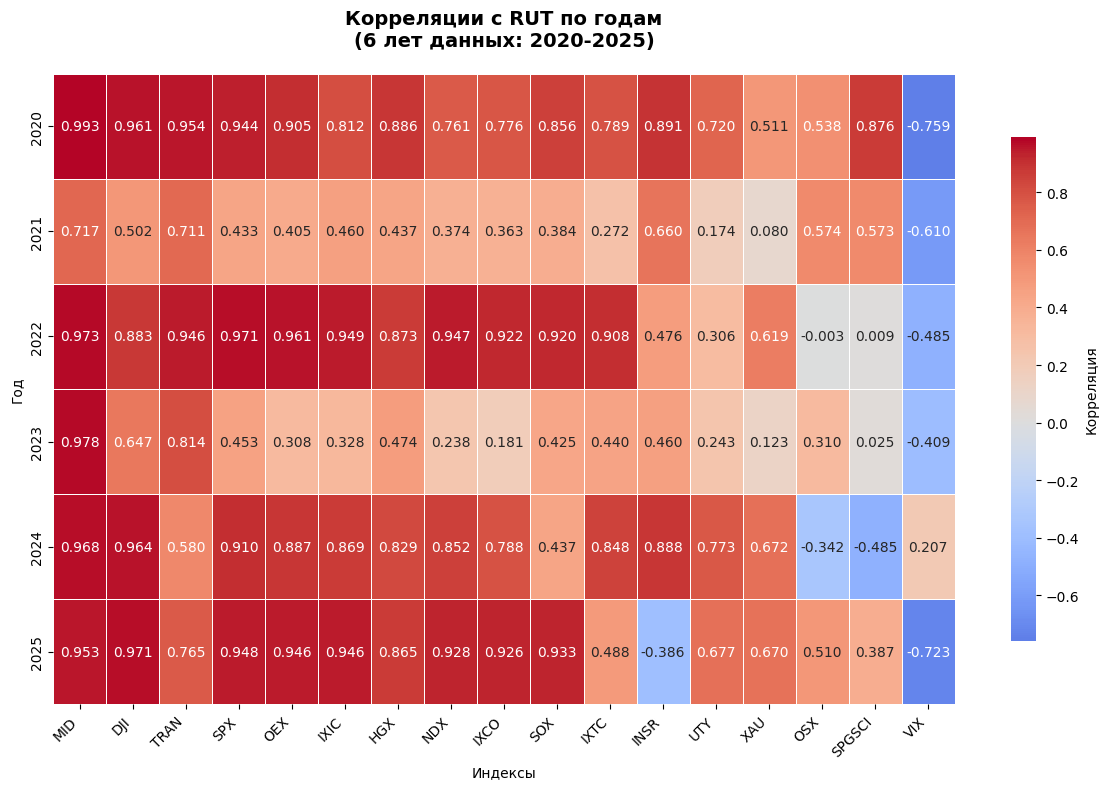

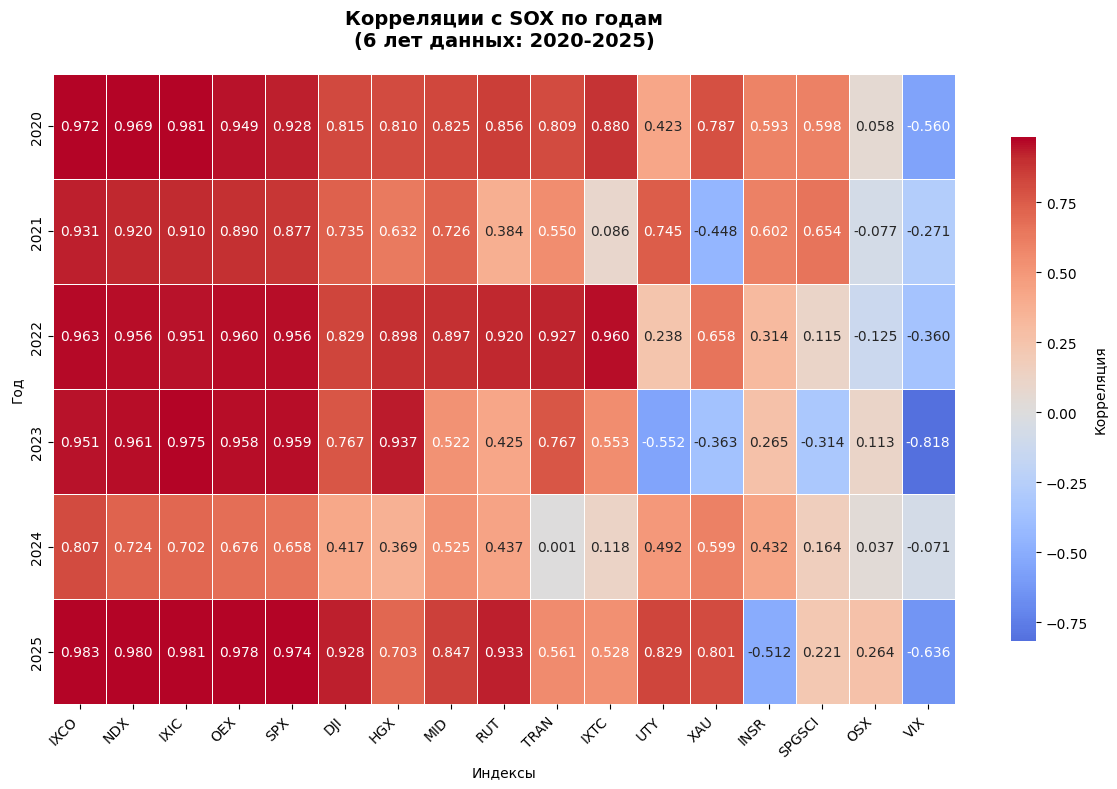

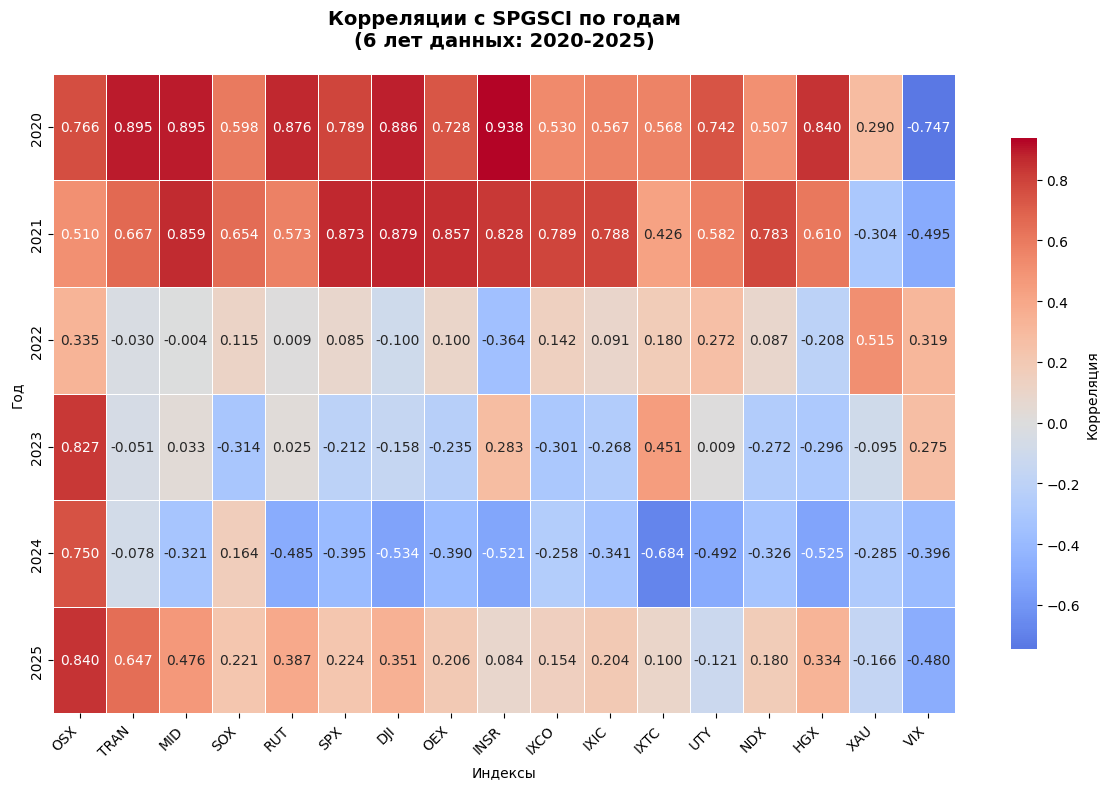

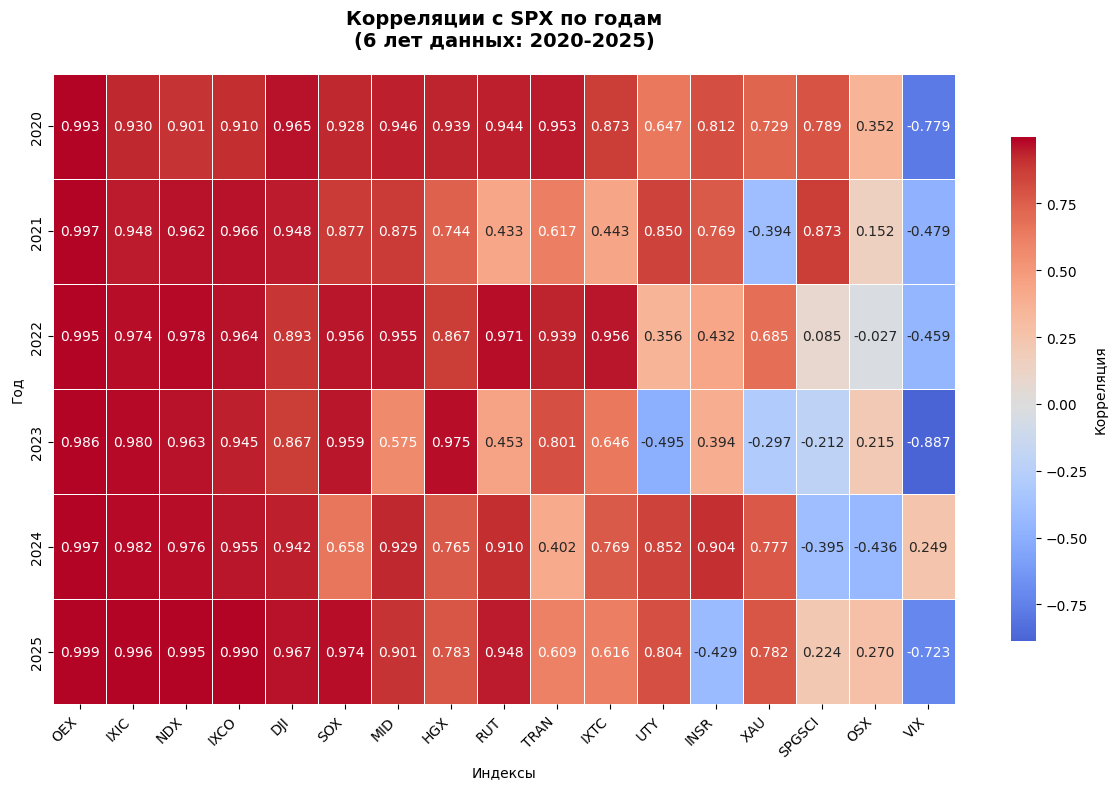

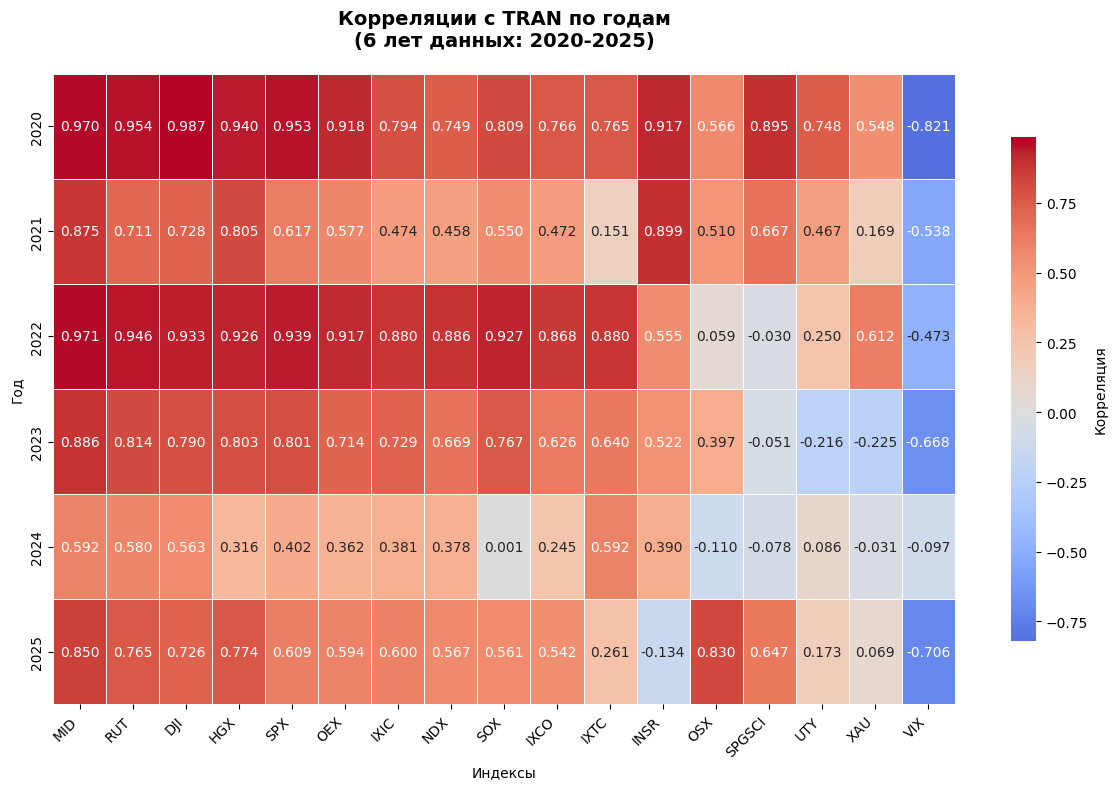

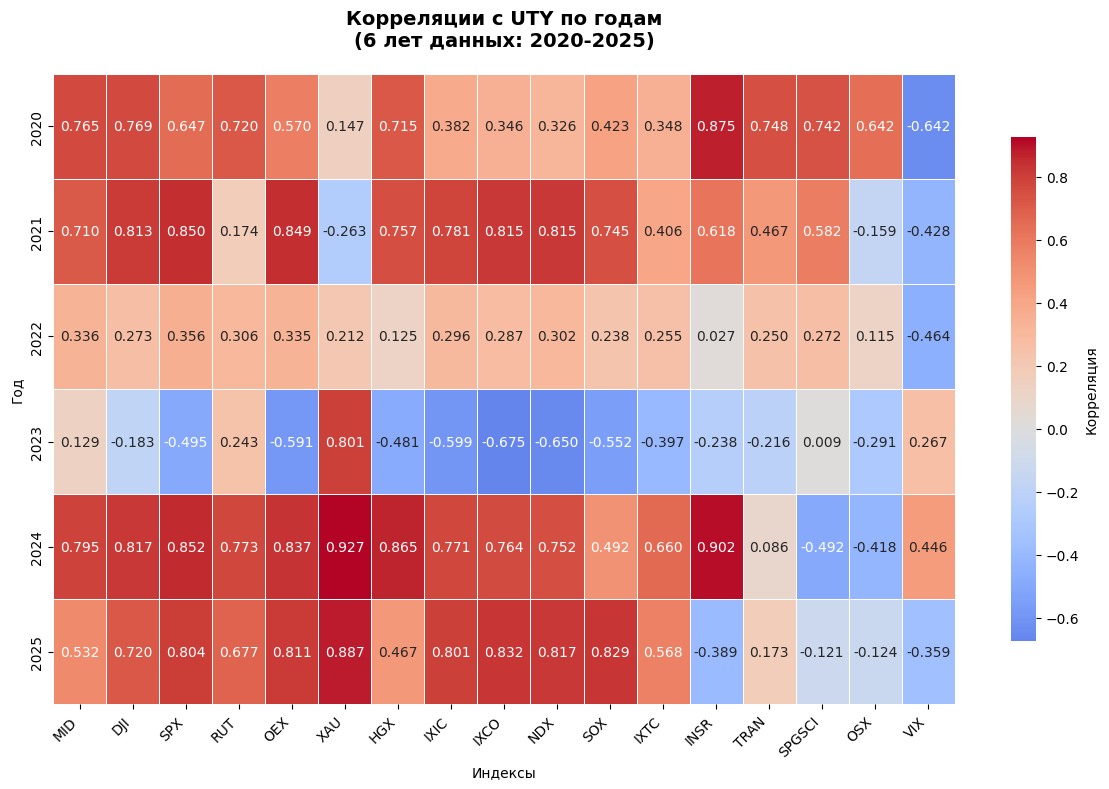

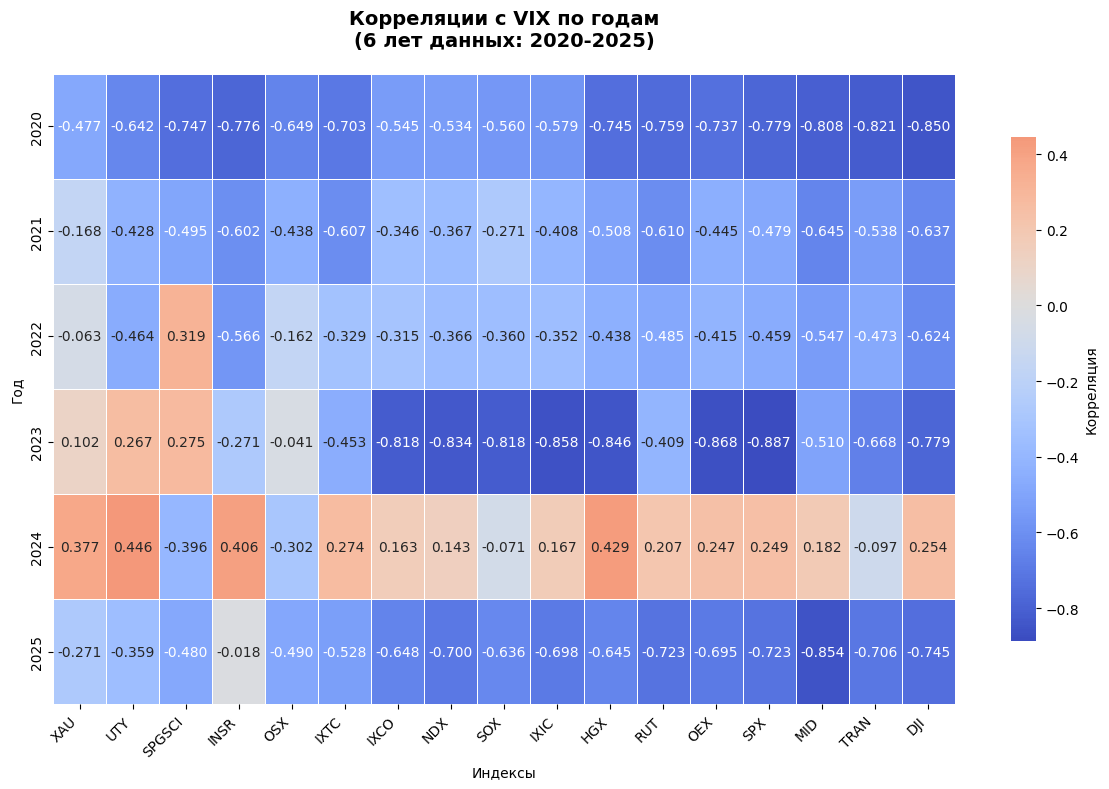

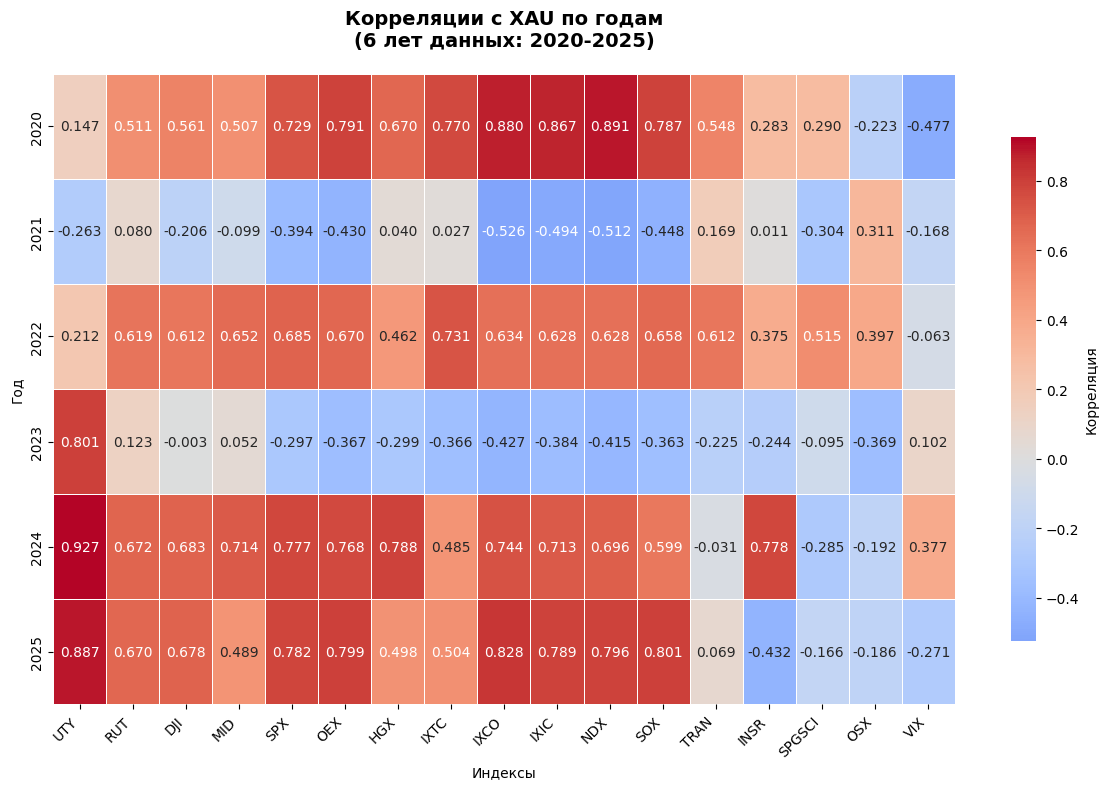

In [35]:
def correlation_heatmaps(data, years_range=range(2020, 2026)):

    close_pivot = data.pivot_table(
        index='Date',
        columns='Ticker',
        values='Close'
    ).dropna(how='all', axis=1)

    all_tickers = close_pivot.columns.tolist()

    valid_tickers = []
    for ticker in all_tickers:
        ticker_data = close_pivot[ticker].dropna()
        if len(ticker_data) > 50:
            valid_tickers.append(ticker)
    
    all_correlation_data = []

    for reference_index in valid_tickers:       
        yearly_correlations = {}
        valid_years = []
        
        for year in years_range:
            year_data = close_pivot[close_pivot.index.year == year]
            
            if len(year_data) > 30 and reference_index in year_data.columns:
                year_data_clean = year_data.dropna(subset=[reference_index])
                if len(year_data_clean) > 20:
                    
                    year_data_filtered = year_data_clean.dropna(axis=1, thresh=20)  # минимум 20 точек
                    if len(year_data_filtered.columns) > 1:
                        corr_matrix = year_data_filtered.corr()
                        yearly_correlations[year] = corr_matrix
                        valid_years.append(year)
        
        if yearly_correlations and len(valid_years) >= 2:
            correlation_trends = []
            
            for year, corr_matrix in yearly_correlations.items():
                if reference_index in corr_matrix.columns:
                    for ticker in corr_matrix.columns:
                        if ticker != reference_index:
                            corr_value = corr_matrix.loc[reference_index, ticker]
                            if not np.isnan(corr_value):
                                correlation_trends.append({
                                    'Year': year,
                                    'Reference': reference_index,
                                    'Ticker': ticker,
                                    'Correlation': corr_value
                                })
                                all_correlation_data.append({
                                    'Year': year,
                                    'Reference': reference_index,
                                    'Ticker': ticker,
                                    'Correlation': corr_value
                                })
            
            if correlation_trends:
                correlation_df = pd.DataFrame(correlation_trends)
                
                pivot_corr = correlation_df.pivot_table(
                    index='Year',
                    columns='Ticker',
                    values='Correlation'
                )
                
                if not pivot_corr.empty:
                    mean_correlations = pivot_corr.mean().sort_values(ascending=False)
                    pivot_corr = pivot_corr[mean_correlations.index]
                    
                    plt.figure(figsize=(12, 8))
                    
                    sns.heatmap(pivot_corr, 
                                annot=True, 
                                cmap='coolwarm', 
                                center=0,
                                fmt='.3f',
                                cbar_kws={'label': 'Корреляция', 'shrink': 0.8},
                                linewidths=0.5,
                                linecolor='white')
                    
                    plt.title(f'Корреляции с {reference_index} по годам\n'
                             f'({len(valid_years)} лет данных: {min(valid_years)}-{max(valid_years)})', 
                             fontsize=14, fontweight='bold', pad=20)
                    plt.xlabel('Индексы')
                    plt.ylabel('Год')
                    plt.xticks(rotation=45, ha='right')
                    plt.tight_layout()
                    plt.show()
    
    return pd.DataFrame(all_correlation_data)

res = correlation_heatmaps(df)

In [ ]:
def report(data, annual_returns, volatility_trends):
    
    # Лучшие и худшие индексы
    best_performers = annual_returns.mean(axis=1).nlargest(5)
    worst_performers = annual_returns.mean(axis=1).nsmallest(5)

    print("Лучшие индексы (по средней доходности):")
    for ticker, return_pct in best_performers.items():
        print(f"  {ticker}: {return_pct:.1f}%")
    
    print("Худшие индексы (по средней доходности):")
    for ticker, return_pct in worst_performers.items():
        print(f"  {ticker}: {return_pct:.1f}%")
    
    stability_ranking = volatility_trends.mean(axis=1).sort_values()
    print(f"Низкая волатильность:")
    for ticker, vol in stability_ranking.head(5).items():
        print(f"  {ticker}: {vol:.2f}")

report(df_an, annual_returns, volatility_trends)

Лучшие индексы (по средней доходности):
  ('IXCO', 'NASDAQ Computer'): 31.9%
  ('SOX', 'PHLX Semiconductor'): 31.2%
  ('NDX', 'NASDAQ 100'): 24.1%
  ('IXIC', 'NASDAQ Composite'): 21.4%
  ('XAU', 'PHLX Gold/Silver'): 20.9%
Худшие индексы (по средней доходности):
  ('SPSIBI', 'S&P Biotechnology'): 0.0%
  ('SPSIOP', 'S&P Oil & Gas Exploration'): 0.0%
  ('OSX', 'PHLX Oil Service'): 1.5%
  ('IXTC', 'NASDAQ Telecommunications'): 5.3%
  ('SPGSCI', 'S&P GSCI Commodity'): 5.6%
Низкая волатильность:
  ('VIX', 'CBOE Volatility'): 5.39
  ('OSX', 'PHLX Oil Service'): 7.83
  ('XAU', 'PHLX Gold/Silver'): 21.09
  ('IXTC', 'NASDAQ Telecommunications'): 27.79
  ('SPGSCI', 'S&P GSCI Commodity'): 36.34


# Вывод итог
1. Данные не содержат пропусков
2. Столбы Dividends и StockSplits не несут смысловой нагрузки при рассмотрении их под индексы
3. За исключением созданных мной столбцов, другие имееют числовой тип => что в данных нет ошибочных данных
4. Выбросы данных присутствуют во всех числовых колонках, но их количество очень мало (меньше 1%), что допустимо. Возможно это какие-то сильные сигналы, которые в дальнейшем повлияют на модель
5. При рассмотрении данных видно, что за некоторые года, у некоторых индексов (SPSIBI и SPSIOP за 2020-2025) нет информации => необходимо учитывать это при обучении модели
6. Признак Volume так же целообразно не учитывать так как у многих индексов он всегда 0
7. По результатам цен закрытия видно, что большинство индексов за полсдение 5 лет выросли в цене
8. Годовое изменение цен за посление 5 лет по всем индексам максимально положительным выпало на 2021 год, за исключением VIX-CBOE Volatility - индекс показал один из самых худших результатов (-32%)
9. Основные индеусы имееют высокую волатильность, остальные же не превышают 500 пунктов
10. За послдение 6 лет каждый индекс имеет хотябы 1 год отрицательно года, при этом отмечается что 2022 год по индексам удачил сильее всего (большие потери в доходности у почти всех индексов)
11. Кореляция индексов не очень зависит между собой, так для многих индексов в один год может возникать сильная корреляция, а в другой отрицательная (слабая)
12. Индекс VIX за последний промежуток времени (6 лет) имеет отрицательную корреляцию со всеми индексами за исключением 2024 года
13. Индекс NASDAQ и его производные показывают наилучшую доходность